In [4]:
# Necessary Libraries

import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt


from nilearn import plotting, datasets, input_data
from nilearn.maskers import NiftiLabelsMasker

/var/folders/y2/55gml_617gzgft7wccv1y28h0000gp/T/ipykernel_59214/1118032623.py:10: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import plotting, datasets, input_data


# First Pass no filtering, heatmap

In [5]:
# setting path to the resting data

base_dir = "/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep"
sub = "sub-10159"

func_dir = os.path.join(base_dir, sub, "func")

bold_file = os.path.join(
    func_dir,
    "sub-10159_task-rest_bold_space-T1w_preproc.nii.gz"
)

mask_file = os.path.join(
    func_dir,
    "sub-10159_task-rest_bold_space-T1w_brainmask.nii.gz"
    
)

confounds_file = os.path.join(
    func_dir,
    "sub-10159_task-rest_bold_confounds.tsv"
)

In [6]:
print("BOLD:", bold_file)
print("Mask:", mask_file)
print("Confounds:", confounds_file)

BOLD: /Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep/sub-10159/func/sub-10159_task-rest_bold_space-T1w_preproc.nii.gz
Mask: /Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep/sub-10159/func/sub-10159_task-rest_bold_space-T1w_brainmask.nii.gz
Confounds: /Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep/sub-10159/func/sub-10159_task-rest_bold_confounds.tsv


In [7]:
# Load and sanity-check
bold_img = nib.load(bold_file)
mask_img = nib.load(mask_file)

print("BOLD shape:", bold_img.shape)   # expect (x, y, z, t)
print("Mask shape:", mask_img.shape)

confounds = pd.read_csv(confounds_file, sep="\t")
print("Confounds shape:", confounds.shape)
confounds.columns[:15]


BOLD shape: (60, 86, 65, 152)
Mask shape: (60, 86, 65)
Confounds shape: (152, 24)


Index(['WhiteMatter', 'GlobalSignal', 'stdDVARS', 'non-stdDVARS',
       'vx-wisestdDVARS', 'FramewiseDisplacement', 'tCompCor00', 'tCompCor01',
       'tCompCor02', 'tCompCor03', 'tCompCor04', 'tCompCor05', 'aCompCor00',
       'aCompCor01', 'aCompCor02'],
      dtype='object')

Using confounds: ['WhiteMatter', 'GlobalSignal', 'FramewiseDisplacement', 'stdDVARS', 'non-stdDVARS', 'vx-wisestdDVARS', 'tCompCor00', 'tCompCor01', 'tCompCor02', 'tCompCor03', 'tCompCor04', 'tCompCor05', 'aCompCor00', 'aCompCor01', 'aCompCor02']


[fetch_atlas_schaefer_2018] Dataset found in /Users/leilanytorresdiaz/nilearn_data/schaefer_2018

/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


Time series shape: (152, 100)
Any NaNs in TS: False
Any infs in TS: False


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


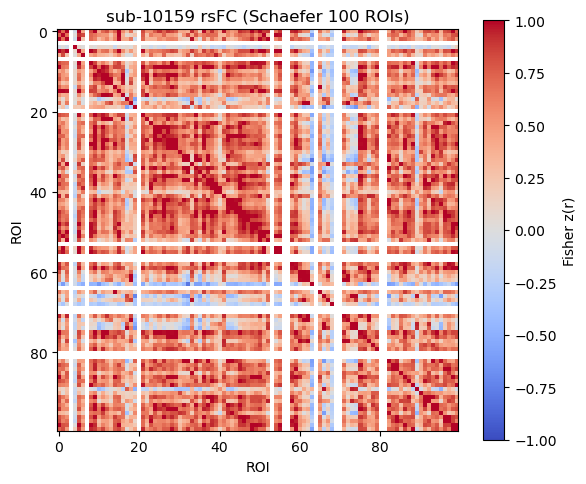

In [8]:
# selecting confounds- signals we don't care about
candidate_confounds = [
    "WhiteMatter",
    "GlobalSignal",
    "FramewiseDisplacement",
    "stdDVARS",
    "non-stdDVARS",
    "vx-wisestdDVARS",
    "tCompCor00", "tCompCor01", "tCompCor02",
    "tCompCor03", "tCompCor04", "tCompCor05",
    "aCompCor00", "aCompCor01", "aCompCor02",
]

confound_cols = [c for c in candidate_confounds if c in confounds.columns]
confounds_used = confounds[confound_cols]
print("Using confounds:", confound_cols)

# 2) Fetch Schaefer 100-ROI atlas (in MNI space)
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = atlas.maps

""" # 3) Set up masker and extract ROI time series
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    mask_img=mask_img,
    standardize=False, # simpler masker
    detrend=True,
    low_pass=None,
    high_pass=None,
    t_r=None
    #2.0,  # change if ds000030 TR is different
) """
""" 
time_series = masker.fit_transform(bold_img, confounds=None)
print("Time series shape (timepoints, ROIs):", time_series.shape) """

masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    mask_img=mask_img,
    standardize=False,   # turn off for debugging
    detrend=False,
    low_pass=None,
    high_pass=None,
    t_r=None,
)

time_series = masker.fit_transform(bold_img, confounds=None)
print("Time series shape:", time_series.shape)
print("Any NaNs in TS:", np.isnan(time_series).any())
print("Any infs in TS:", np.isinf(time_series).any())

# 4) Compute rsFC matrix
corr = np.corrcoef(time_series.T)
z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))

plt.figure(figsize=(6, 5))
im = plt.imshow(z_corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, label="Fisher z(r)")
plt.title("sub-10159 rsFC (Schaefer 100 ROIs)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()


3/18 – Set up first rsFC pipeline for ds000030.
– Identified and downloaded the key fMRIPrep outputs for one subject’s resting run: preprocessed 4D BOLD NIfTI, corresponding brain mask, and confounds TSV. These provide the time‑series data, define in‑brain voxels, and capture nuisance signals (e.g., white‑matter, global signal, motion) to regress out.
– Loaded the Schaefer 100‑ROI atlas and used NiftiLabelsMasker to extract average BOLD time series per ROI. For today I used a deliberately simple masker (no standardization or temporal filtering) to avoid NaN issues and verify the basic pipeline.
– Computed the ROI‑by‑ROI correlation matrix, applied a Fisher z‑transform, and plotted it as a heatmap. Red values indicate strong positive correlations between pairs of ROIs (within or between networks); this high overall correlation pattern is expected for a single subject with minimal denoising and a relatively short rest period.

– Tomorrow: gradually re‑introduce confound regression, standardization, and band‑pass filtering, then compare how these choices change the rsFC matrix and the apparent strength of within‑ vs between‑network connections.



Visualizing networks:
Static 2D brain maps: Nilearn can plot the Schaefer atlas or specific networks on glass brains or surface views (e.g., plotting.plot_roi, plotting.view_img_on_surf).
​

3D interactive views: functions like plotting.view_connectome let you draw ROIs as nodes in 3D space with lines for connections above a threshold, viewable in the browser.
​

You can group ROIs by Yeo networks or Schaefer network labels to show within‑ and between‑network connectivity more explicitly.



# Tue March 31st: clearer heatmaps and visuals of networks in this one person

In [13]:
# Yeo 7 Networks variables
# ── Network label definitions (run this once) ─────────────────────────────────

# Decode atlas labels (handles both bytes and strings)
atlas_labels = list(atlas.labels)
atlas_labels = [l.decode() if isinstance(l, bytes) else l for l in atlas_labels]

# Extract network name from each label
# Schaefer format: "7Networks_LH_Vis_1" → index 2 = network abbreviation
network_names = []
for lbl in atlas_labels:
    parts = lbl.split("_")
    network_names.append(parts[2] if len(parts) > 2 else "Unknown")

# Yeo 7 network order, colors, and full names
unique_nets = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
net_colors  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf"]
net_label_full = {
    "Vis":         "Visual",
    "SomMot":      "Somatomotor",
    "DorsAttn":    "Dorsal Attention",
    "SalVentAttn": "Ventral Attention",
    "Limbic":      "Limbic",
    "Cont":        "Frontoparietal",
    "Default":     "Default Mode",
}

# Network boundary positions (for heatmap divider lines)
nets_sorted_order = []
for i in range(len(atlas_labels)):
    nets_sorted_order.append(network_names[i])

boundaries, ticks, tick_labels, tick_colors = [], [], [], []

# Sort ROI indices by network
sort_idx = sorted(range(len(atlas_labels)),
                  key=lambda i: unique_nets.index(network_names[i])
                  if network_names[i] in unique_nets else 99)
nets_sorted = [network_names[i] for i in sort_idx]

prev = None
for i, n in enumerate(nets_sorted):
    if n != prev:
        boundaries.append(i)
        prev = n
boundaries.append(len(atlas_labels))

for k in range(len(boundaries) - 1):
    mid = (boundaries[k] + boundaries[k+1]) / 2
    net = nets_sorted[boundaries[k]]
    ticks.append(mid)
    tick_labels.append(net_label_full.get(net, net))
    tick_colors.append(net_colors[unique_nets.index(net)]
                       if net in unique_nets else "gray")

print("Networks found in atlas:", set(network_names))
print("ROIs per network:")
for n in unique_nets:
    count = network_names.count(n)
    print(f"  {net_label_full[n]:25s}: {count} ROIs")

Networks found in atlas: {'SalVentAttn', 'Vis', 'Default', 'DorsAttn', 'Limbic', 'SomMot', 'Unknown', 'Cont'}
ROIs per network:
  Visual                   : 17 ROIs
  Somatomotor              : 14 ROIs
  Dorsal Attention         : 15 ROIs
  Ventral Attention        : 12 ROIs
  Limbic                   : 5 ROIs
  Frontoparietal           : 13 ROIs
  Default Mode             : 24 ROIs


In [10]:
import pandas as pd

confounds = pd.read_csv(confounds_file, sep="\t")
print(confounds.columns.tolist())  # inspect available columns

candidate_confounds = [
    "X", "Y", "Z", "RotX", "RotY", "RotZ",           # motion (older fMRIPrep names)
    "WhiteMatter", "CSF",
    "aCompCor00", "aCompCor01", "aCompCor02",
    "aCompCor03", "aCompCor04", "aCompCor05",
    "FramewiseDisplacement", "stdDVARS",
]
# Also try newer names if older ones missing:
candidate_confounds += [
    "trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z",
    "trans_x_derivative1", "trans_y_derivative1", "trans_z_derivative1",
    "rot_x_derivative1", "rot_y_derivative1", "rot_z_derivative1",
]

confound_cols  = [c for c in candidate_confounds if c in confounds.columns]
confounds_used = confounds[confound_cols].fillna(0)
print("Using confounds:", confound_cols)

['WhiteMatter', 'GlobalSignal', 'stdDVARS', 'non-stdDVARS', 'vx-wisestdDVARS', 'FramewiseDisplacement', 'tCompCor00', 'tCompCor01', 'tCompCor02', 'tCompCor03', 'tCompCor04', 'tCompCor05', 'aCompCor00', 'aCompCor01', 'aCompCor02', 'aCompCor03', 'aCompCor04', 'aCompCor05', 'X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ']
Using confounds: ['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ', 'WhiteMatter', 'aCompCor00', 'aCompCor01', 'aCompCor02', 'aCompCor03', 'aCompCor04', 'aCompCor05', 'FramewiseDisplacement', 'stdDVARS']


In [11]:
# adding high pass back into the masker since no longer using load_confounders
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    mask_img=mask_img,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,    # ← put back now that load_confounds is not involved
    t_r=2.0,
    memory="nilearn_cache",
    verbose=1,
)

time_series = masker.fit_transform(bold_img, confounds=confounds_used)

[NiftiLabelsMasker.wrapped] loading data from 
/Users/leilanytorresdiaz/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz

[NiftiLabelsMasker.wrapped] loading mask from 
Nifti1Image('/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep/sub-10159/fun
c/sub-10159_task-rest_bold_space-T1w_brainmask.nii.gz')

[NiftiLabelsMasker.wrapped] Resampling labels

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract(<nibabel.nifti1.Nifti1Image object at 0x17fb42120>, <nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x312730980>, { 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'keep_masked_labels': True,
  'labels': None,
  'labels_img': '/Users/leilanytorresdiaz/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz',
  'low_pass': 0.1,
  'lut': None,
  'mask_img': <nibabel.nifti1.Nifti1Image object at 0x17fc72bd0>,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  'strategy': 'mean',
  't_r': 2.0,
  'target_affine': None,
  'target_shape': None}, confounds=[             X         Y    

[NiftiLabelsMasker.wrapped] Loading data from 
Nifti1Image('/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep/sub-10159/fun
c/sub-10159_task-rest_bold_space-T1w_preproc.nii.gz')

[NiftiLabelsMasker.wrapped] Extracting region signals

/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


[NiftiLabelsMasker.wrapped] Cleaning extracted signals

_______________________________________________filter_and_extract - 1.4s, 0.0min


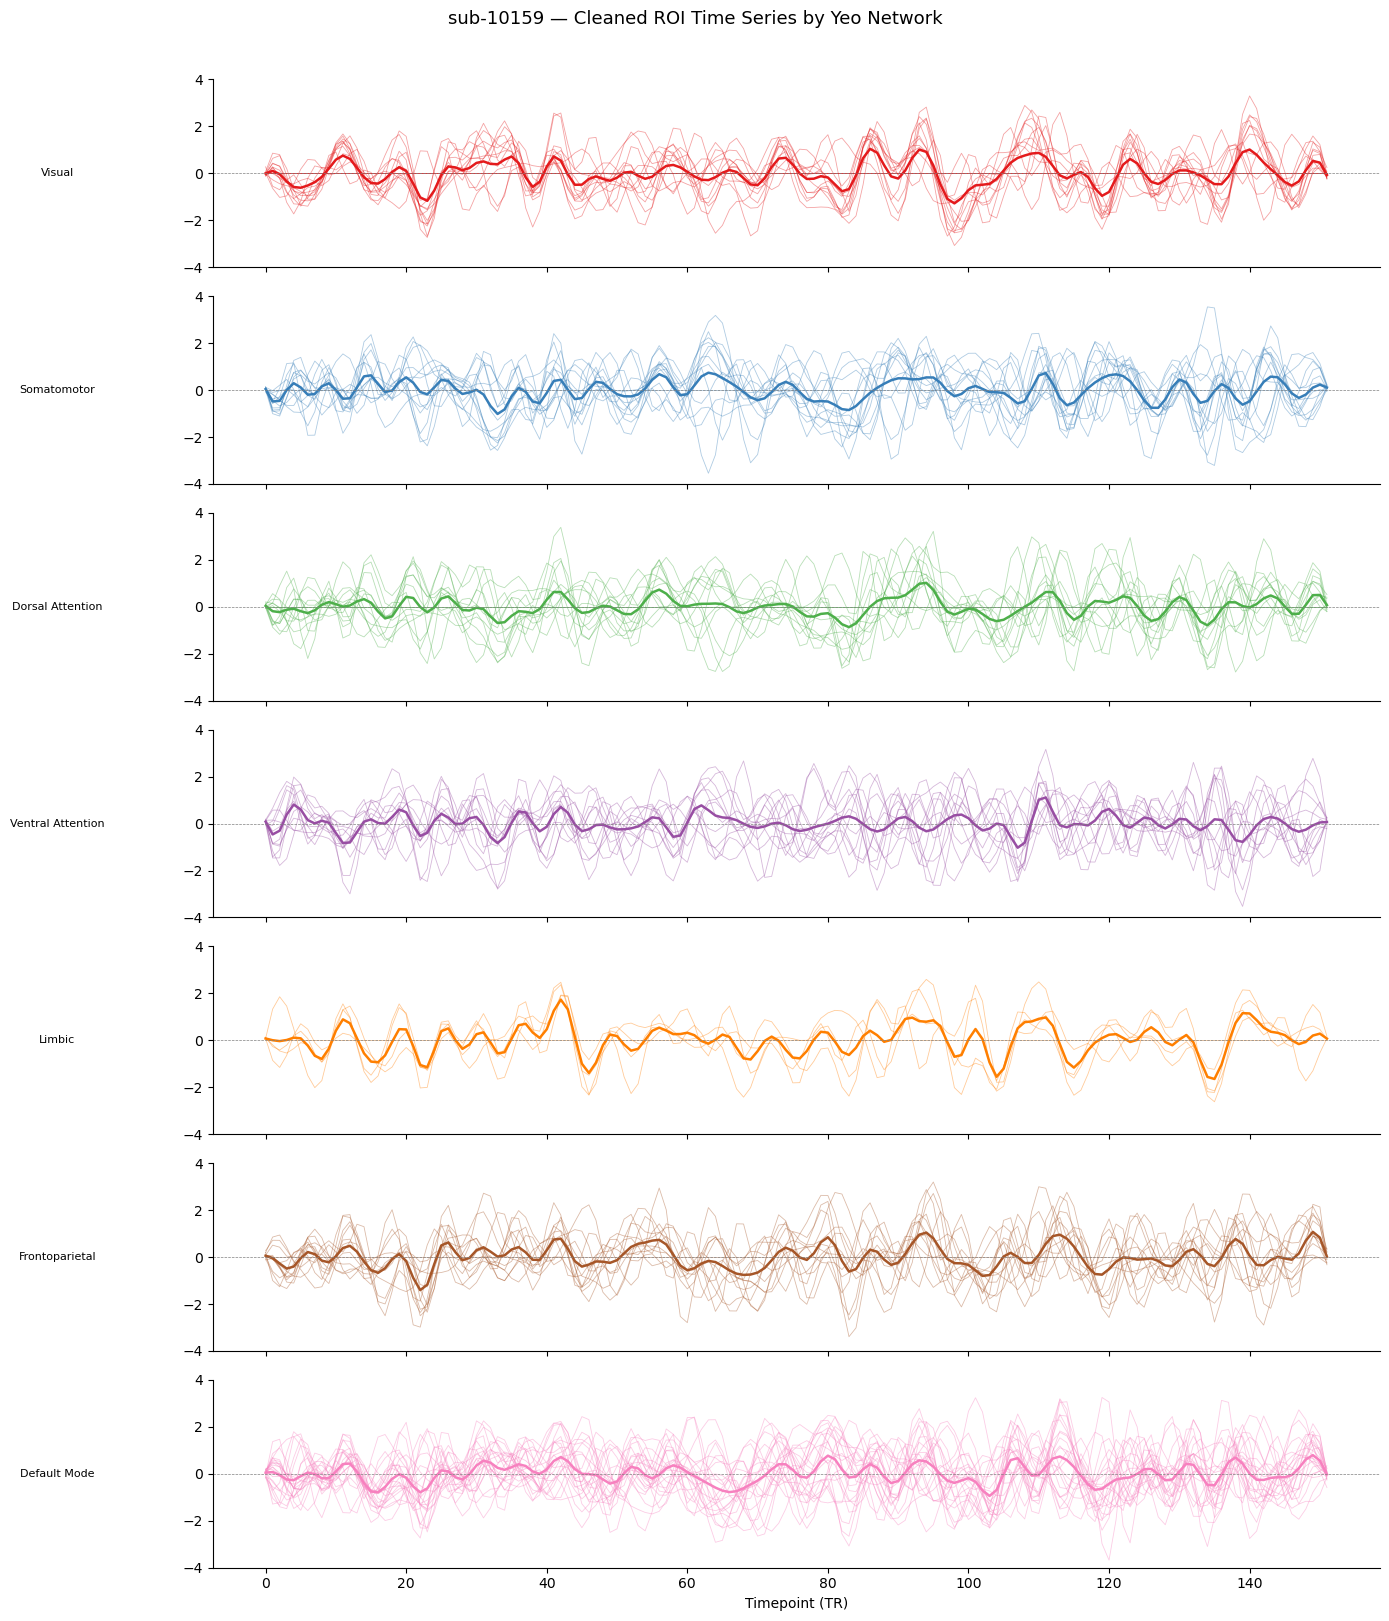

In [15]:
# plot of BOLD signal for every ROI, colored by the 7 Yeo Networks
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)

for ax, net in zip(axes, unique_nets):
    idx = [i for i, n in enumerate(network_names) if n == net and i <
    time_series.shape[1]]
    color = net_colors[unique_nets.index(net)]
    for i in idx:
        ax.plot(time_series[:, i], color=color, alpha=0.4, linewidth=0.6)
    # Mean signal for that network in bold
    ax.plot(time_series[:, idx].mean(axis=1), color=color, linewidth=1.8,
            label=net_label_full[net])
    ax.set_ylabel(net_label_full[net], fontsize=8, rotation=0,
                  labelpad=90, va="center")
    ax.set_ylim(-4, 4)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

axes[-1].set_xlabel("Timepoint (TR)")
fig.suptitle("sub-10159 — Cleaned ROI Time Series by Yeo Network", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("timeseries_by_network.png", dpi=150)
plt.show()


In [ ]:
# 3D visualization of the 7 networks as colored regions + their connections using 3D Glass Brain Connectome
### This opens interactive version in a new tab!!!!

from nilearn import plotting
import numpy as np

# Get ROI centroid coordinates in MNI space
coords = plotting.find_parcellation_cut_coords(atlas_img)

# Compute FC matrix from your cleaned time series
corr   = np.corrcoef(time_series.T)
z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))
np.fill_diagonal(z_corr, 0)

# Color each node by its Yeo network
node_colors = [net_colors[unique_nets.index(network_names[i])]
               if network_names[i] in unique_nets else "gray"
               for i in range(len(network_names))]

# 3D interactive HTML — opens in browser
view = plotting.view_connectome(
    z_corr,
    coords,
    edge_threshold="95%",       # top 5% strongest connections
    node_color=node_colors,
    node_size=6,
    colorbar=True,
    title="sub-10159 rsFC — Yeo 7 Networks"
)
view.save_as_html("rsFC_3D_connectome.html")
view.open_in_browser()   # opens interactive 3D in your browser

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# colormap of networks
# Plot each network's ROIs as a colored patch on the cortical surface
view_surf = plotting.view_img_on_surf(
    atlas_img,
    surf_mesh="fsaverage5",
    title="Schaefer 100 ROIs — Yeo 7 Networks",
    cmap="tab10",
    symmetric_cmap=False,
    colorbar=False,
)
view_surf.save_as_html("rsFC_surface_networks.html")
view_surf.open_in_browser()

/var/folders/y2/55gml_617gzgft7wccv1y28h0000gp/T/ipykernel_59214/389124836.py:3: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  view_surf = plotting.view_img_on_surf(


In [21]:
# Safe network index extraction — clamp to actual matrix size
n_rois = z_corr.shape[0]  # = 100

net_matrix = np.zeros((7, 7))
for i, ni in enumerate(unique_nets):
    for j, nj in enumerate(unique_nets):
        # Clamp indices to valid range
        idx_i = [k for k, n in enumerate(network_names) if n == ni and k < n_rois]
        idx_j = [k for k, n in enumerate(network_names) if n == nj and k < n_rois]
        
        if len(idx_i) == 0 or len(idx_j) == 0:
            continue
            
        sub = z_corr[np.ix_(idx_i, idx_j)]
        vals = sub[np.triu_indices(len(idx_i), k=1)] if i == j else sub.flatten()
        net_matrix[i, j] = vals.mean() if len(vals) > 0 else 0

# Run this right after your atlas label definitions cell
# Strip background label if present
if len(atlas_labels) == time_series.shape[1] + 1:
    atlas_labels  = atlas_labels[1:]   # drop index 0 (background)
    network_names = network_names[1:]  # drop corresponding network entry
    print("Stripped background label — now:", len(atlas_labels), "ROIs")

Stripped background label — now: 100 ROIs


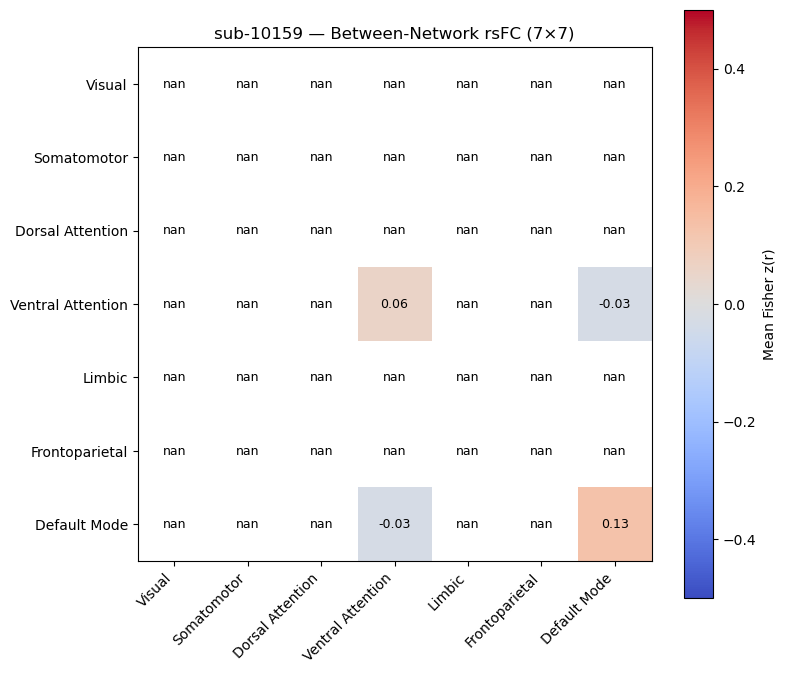

In [22]:
full_names = [net_label_full[n] for n in unique_nets]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(net_matrix, cmap="coolwarm", vmin=-0.5, vmax=0.5)
plt.colorbar(im, ax=ax, label="Mean Fisher z(r)")
ax.set_xticks(range(7)); ax.set_xticklabels(full_names, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(full_names)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{net_matrix[i,j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if abs(net_matrix[i,j]) > 0.3 else "black")
ax.set_title("sub-10159 — Between-Network rsFC (7×7)")
plt.tight_layout()
plt.savefig("rsFC_network_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## the issue with the multiple nan is a label mismatch, the network name strings in network_names don't match the strings in unique_nets for the other 5 networks

In [23]:
# running diagnosis
print("Unique values in network_names:", set(network_names))
print("unique_nets list:", unique_nets)

Unique values in network_names: {'SalVentAttn', 'Vis', 'Default', 'DorsAttn', 'Limbic', 'SomMot', 'Cont'}
unique_nets list: ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']


In [24]:
## z correlation is stale??
print("Any NaNs in time_series:", np.isnan(time_series).any())
print("Any NaNs in z_corr:", np.isnan(z_corr).any())
print("How many NaNs in z_corr:", np.isnan(z_corr).sum())

# Check a specific network pair manually
idx_vis = [k for k, n in enumerate(network_names) if n == "Vis"]
idx_som = [k for k, n in enumerate(network_names) if n == "SomMot"]
print("Vis indices:", idx_vis)
print("SomMot indices:", idx_som)
print("Sample z_corr[Vis, SomMot]:", z_corr[np.ix_(idx_vis, idx_som)])

Any NaNs in time_series: False
Any NaNs in z_corr: True
How many NaNs in z_corr: 2068
Vis indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 50, 51, 52, 53, 54, 55, 56, 57]
SomMot indices: [9, 10, 11, 12, 13, 14, 58, 59, 60, 61, 62, 63, 64, 65]
Sample z_corr[Vis, SomMot]: [[ 0.17892768  0.07188738 -0.00260565  0.15942479 -0.03746988 -0.08997565
   0.36907508  0.21212502  0.20339747 -0.12300516 -0.1103496   0.0142617
          nan -0.11933399]
 [ 0.09827106 -0.20332069 -0.2334889  -0.20590899 -0.27649295  0.38318757
   0.44198576  0.24791163 -0.32629327 -0.39893912 -0.62658968  0.1375961
          nan  0.13681483]
 [ 0.18840251  0.09367839  0.05082448  0.11885585 -0.21473966 -0.10059723
   0.40709933  0.35927944  0.11140862 -0.1461159  -0.24772765 -0.06475435
          nan -0.35624928]
 [        nan         nan         nan         nan         nan         nan
          nan         nan         nan         nan         nan         nan
          nan         nan]
 [ 0.22054775  0.37707242  0.39229245  0.21

 ## specific ROIs had constant time series (zero variance after filtering) and np.corrcoef returns nan when it tries to divide by zero

In [25]:
# running to identify which ROI are "dead"
# Find zero-variance ROIs
stds = time_series.std(axis=0)
bad_rois = np.where(stds == 0)[0]
near_zero = np.where(stds < 0.01)[0]
print("Zero variance ROIs:", bad_rois)
print("Near-zero variance ROIs:", near_zero)
print("Their networks:", [network_names[i] for i in bad_rois])
print("Their stds:", stds[bad_rois])

Zero variance ROIs: [ 3  7 20 53 56 57 64 69 70 80 81]
Near-zero variance ROIs: [ 3  7 20 53 56 57 64 69 70 80 81]
Their networks: ['Vis', 'Vis', 'DorsAttn', 'Vis', 'Vis', 'Vis', 'SomMot', 'DorsAttn', 'DorsAttn', 'Cont', 'Cont']
Their stds: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [26]:
# now dropping these zero variance ROI
# Drop zero/near-zero variance ROIs
good_mask   = stds > 0.01
good_rois   = np.where(good_mask)[0]
ts_clean    = time_series[:, good_rois]
names_clean = [network_names[i] for i in good_rois]

print(f"Dropped {100 - len(good_rois)} bad ROIs, kept {len(good_rois)}")
print("Dropped networks:", [network_names[i] for i in np.where(~good_mask)[0]])

# Recompute z_corr cleanly
corr   = np.corrcoef(ts_clean.T)
z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))
np.fill_diagonal(z_corr, 0)

print("NaNs remaining in z_corr:", np.isnan(z_corr).sum())  # should be 0

Dropped 11 bad ROIs, kept 89
Dropped networks: ['Vis', 'Vis', 'DorsAttn', 'Vis', 'Vis', 'Vis', 'SomMot', 'DorsAttn', 'DorsAttn', 'Cont', 'Cont']
NaNs remaining in z_corr: 0


In [27]:
# recomputing after dropping the zero variance

n_rois = z_corr.shape[0]
net_matrix = np.zeros((7, 7))

for i, ni in enumerate(unique_nets):
    for j, nj in enumerate(unique_nets):
        idx_i = [k for k, n in enumerate(names_clean) if n == ni]
        idx_j = [k for k, n in enumerate(names_clean) if n == nj]
        if len(idx_i) == 0 or len(idx_j) == 0:
            net_matrix[i, j] = np.nan
            continue
        sub  = z_corr[np.ix_(idx_i, idx_j)]
        vals = sub[np.triu_indices(len(idx_i), k=1)] if i == j else sub.flatten()
        net_matrix[i, j] = vals.mean() if len(vals) > 0 else np.nan

print("NaNs in net_matrix:", np.isnan(net_matrix).sum())  # should be 0

NaNs in net_matrix: 0


In [28]:
# rerunning after clean, remove nans
n_rois = z_corr.shape[0]
net_matrix = np.zeros((7, 7))

for i, ni in enumerate(unique_nets):
    for j, nj in enumerate(unique_nets):
        idx_i = [k for k, n in enumerate(names_clean) if n == ni]
        idx_j = [k for k, n in enumerate(names_clean) if n == nj]
        if len(idx_i) == 0 or len(idx_j) == 0:
            net_matrix[i, j] = np.nan
            continue
        sub  = z_corr[np.ix_(idx_i, idx_j)]
        vals = sub[np.triu_indices(len(idx_i), k=1)] if i == j else sub.flatten()
        net_matrix[i, j] = vals.mean() if len(vals) > 0 else np.nan

print("NaNs in net_matrix:", np.isnan(net_matrix).sum())  # should be 0

NaNs in net_matrix: 0


In [31]:
# defining cords clean
from nilearn import plotting

# Node colors aligned to clean ROI set
node_colors_clean = [net_colors[unique_nets.index(n)]
                     if n in unique_nets else "gray"
                     for n in names_clean]

print("node_colors_clean length:", len(node_colors_clean))  # should match z_corr dim
# Get all ROI centroids from atlas
coords_all = plotting.find_parcellation_cut_coords(atlas_img)
print("coords_all shape:", coords_all.shape)  # likely (101, 3) or (100, 3)

# Align to good_rois depending on whether background was included
if coords_all.shape[0] == 101:
    coords_clean = coords_all[1:][good_rois]   # strip background first, then filter
elif coords_all.shape[0] == 100:
    coords_clean = coords_all[good_rois]        # no background, just filter

print("coords_clean shape:", coords_clean.shape)  # should match z_corr, e.g. (89, 3)
print("z_corr shape:",       z_corr.shape)         # e.g. (89, 89)
print("names_clean length:", len(names_clean))     # e.g. 89
print("node_colors_clean:",  len(node_colors_clean)) # e.g. 89
# All first numbers must match

node_colors_clean length: 89
coords_all shape: (100, 3)
coords_clean shape: (89, 3)
z_corr shape: (89, 89)
names_clean length: 89
node_colors_clean: 89


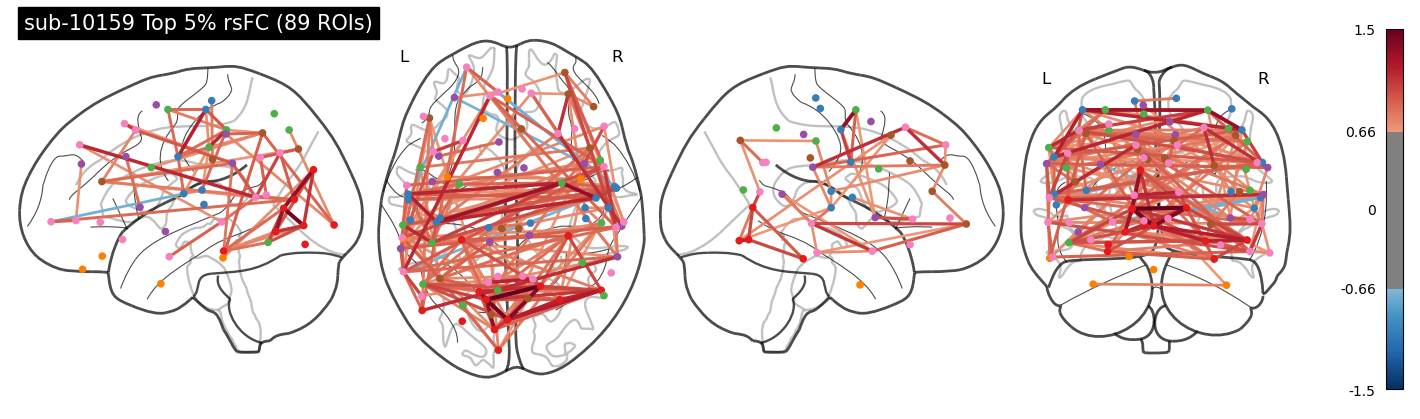

In [32]:
fig = plt.figure(figsize=(14, 4))
plotting.plot_connectome(
    z_corr, coords_clean,
    edge_threshold="95%",
    node_color=node_colors_clean,
    node_size=20,
    colorbar=True,
    title=f"sub-10159 Top 5% rsFC ({len(names_clean)} ROIs)",
    figure=fig,
    display_mode="lzry",
)
plt.savefig("rsFC_connectome_clean.png", dpi=200, bbox_inches="tight")
plt.show()

## Cleaned heatmaps with 11 dropped ROI

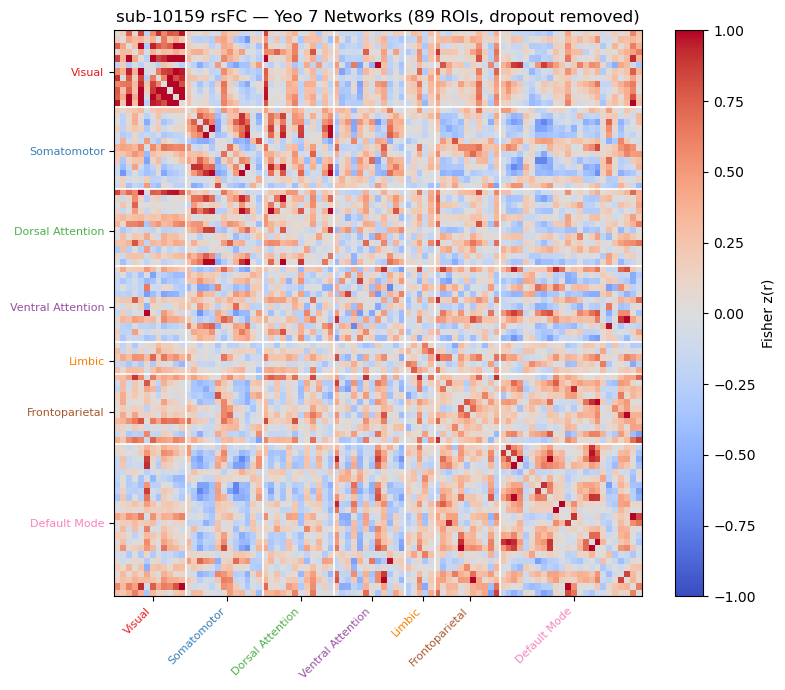

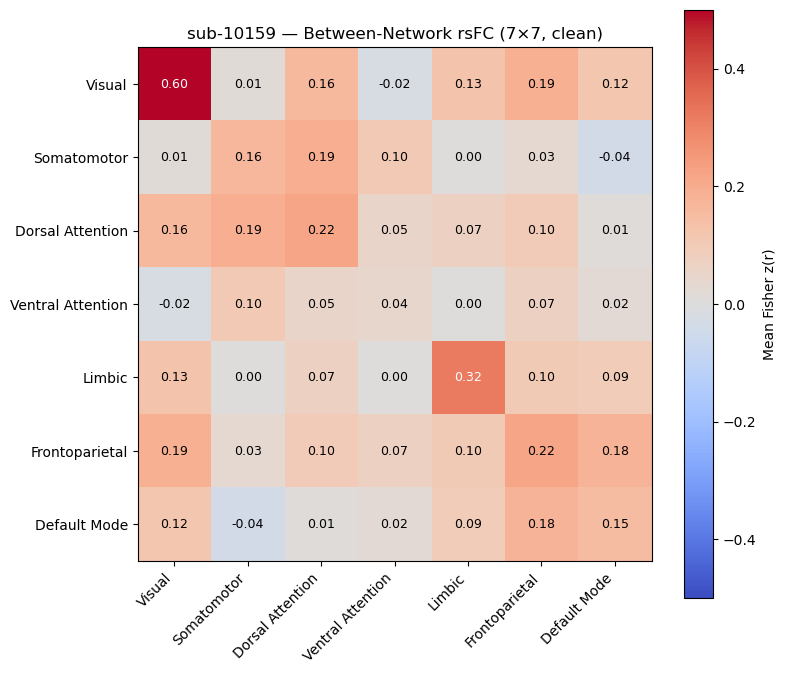

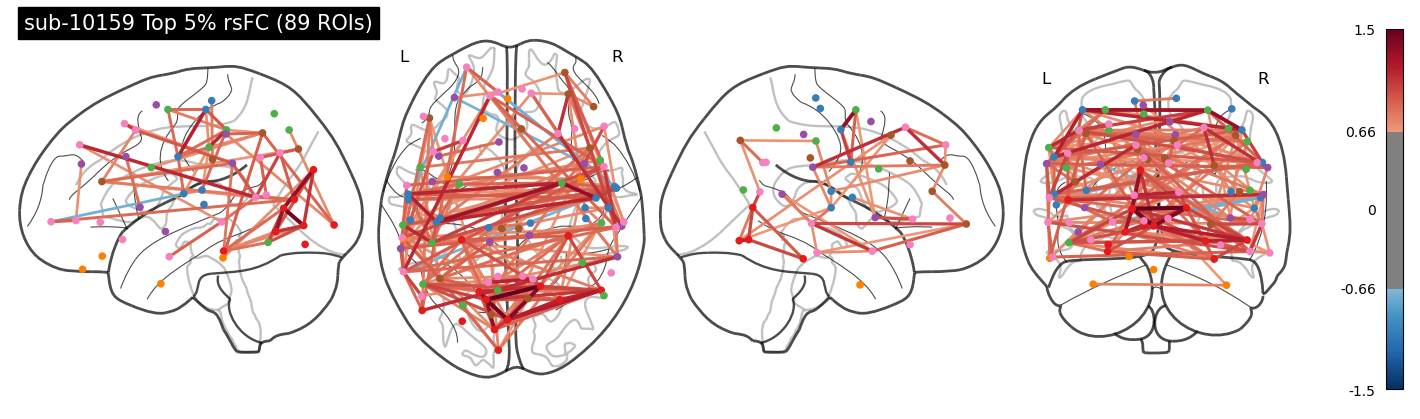

In [33]:
# plots with clean version now
# ── 4. Network sorted heatmap ─────────────────────────────────────────────────
# Replace network_names → names_clean, z_corr stays the same (already clean)

sort_idx_clean = sorted(range(len(names_clean)),
                        key=lambda i: unique_nets.index(names_clean[i])
                        if names_clean[i] in unique_nets else 99)
z_sorted = z_corr[np.ix_(sort_idx_clean, sort_idx_clean)]

# Recompute boundaries for clean set
nets_sorted_clean = [names_clean[i] for i in sort_idx_clean]
boundaries_c, ticks_c, tick_labels_c, tick_colors_c = [], [], [], []
prev = None
for i, n in enumerate(nets_sorted_clean):
    if n != prev:
        boundaries_c.append(i)
        prev = n
boundaries_c.append(len(names_clean))
for k in range(len(boundaries_c) - 1):
    mid = (boundaries_c[k] + boundaries_c[k+1]) / 2
    net = nets_sorted_clean[boundaries_c[k]]
    ticks_c.append(mid)
    tick_labels_c.append(net_label_full.get(net, net))
    tick_colors_c.append(net_colors[unique_nets.index(net)] if net in unique_nets else "gray")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(z_sorted, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
plt.colorbar(im, ax=ax, label="Fisher z(r)")
for b in boundaries_c[1:-1]:
    ax.axhline(b-0.5, color="white", lw=1.2)
    ax.axvline(b-0.5, color="white", lw=1.2)
ax.set_xticks(ticks_c); ax.set_xticklabels(tick_labels_c, rotation=45, ha="right", fontsize=8)
ax.set_yticks(ticks_c); ax.set_yticklabels(tick_labels_c, fontsize=8)
for tick, color in zip(ax.get_xticklabels(), tick_colors_c): tick.set_color(color)
for tick, color in zip(ax.get_yticklabels(), tick_colors_c): tick.set_color(color)
ax.set_title(f"sub-10159 rsFC — Yeo 7 Networks ({len(names_clean)} ROIs, dropout removed)")
plt.tight_layout()
plt.savefig("rsFC_network_sorted_clean.png", dpi=200, bbox_inches="tight")
plt.show()

# ── 5. 7x7 network matrix ─────────────────────────────────────────────────────
full_names = [net_label_full[n] for n in unique_nets]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(net_matrix, cmap="coolwarm", vmin=-0.5, vmax=0.5)
plt.colorbar(im, ax=ax, label="Mean Fisher z(r)")
ax.set_xticks(range(7)); ax.set_xticklabels(full_names, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(full_names)
for i in range(7):
    for j in range(7):
        val = net_matrix[i,j]
        txt = f"{val:.2f}" if not np.isnan(val) else "n/a"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                color="white" if abs(val) > 0.3 else "black")
ax.set_title("sub-10159 — Between-Network rsFC (7×7, clean)")
plt.tight_layout()
plt.savefig("rsFC_network_matrix_clean.png", dpi=200, bbox_inches="tight")
plt.show()

# ── 6. Glass brain connectome ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 4))
plotting.plot_connectome(
    z_corr, coords_clean,
    edge_threshold="95%",
    node_color=node_colors_clean,
    node_size=20,
    colorbar=True,
    title=f"sub-10159 Top 5% rsFC ({len(names_clean)} ROIs)",
    figure=fig,
    display_mode="lzry",
)
plt.savefig("rsFC_connectome_clean.png", dpi=200, bbox_inches="tight")
plt.show()

# Recovering the dropped ROI, without nan issue -4/1/26

In [ ]:
# Yeo 7 Networks variables
# ── Network label definitions (run this once) ─────────────────────────────────

# Decode atlas labels (handles both bytes and strings)
atlas_labels = list(atlas.labels)
atlas_labels = [l.decode() if isinstance(l, bytes) else l for l in atlas_labels]

# Extract network name from each label
# Schaefer format: "7Networks_LH_Vis_1" → index 2 = network abbreviation
network_names = []
for lbl in atlas_labels:
    parts = lbl.split("_")
    network_names.append(parts[2] if len(parts) > 2 else "Unknown")

# Yeo 7 network order, colors, and full names
unique_nets = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
net_colors  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf"]
net_label_full = {
    "Vis":         "Visual",
    "SomMot":      "Somatomotor",
    "DorsAttn":    "Dorsal Attention",
    "SalVentAttn": "Ventral Attention",
    "Limbic":      "Limbic",
    "Cont":        "Frontoparietal",
    "Default":     "Default Mode",
}

# Network boundary positions (for heatmap divider lines)
nets_sorted_order = []
for i in range(len(atlas_labels)):
    nets_sorted_order.append(network_names[i])

boundaries, ticks, tick_labels, tick_colors = [], [], [], []

# Sort ROI indices by network
sort_idx = sorted(range(len(atlas_labels)),
                  key=lambda i: unique_nets.index(network_names[i])
                  if network_names[i] in unique_nets else 99)
nets_sorted = [network_names[i] for i in sort_idx]

prev = None
for i, n in enumerate(nets_sorted):
    if n != prev:
        boundaries.append(i)
        prev = n
boundaries.append(len(atlas_labels))

for k in range(len(boundaries) - 1):
    mid = (boundaries[k] + boundaries[k+1]) / 2
    net = nets_sorted[boundaries[k]]
    ticks.append(mid)
    tick_labels.append(net_label_full.get(net, net))
    tick_colors.append(net_colors[unique_nets.index(net)]
                       if net in unique_nets else "gray")

print("Networks found in atlas:", set(network_names))
print("ROIs per network:")
for n in unique_nets:
    count = network_names.count(n)
    print(f"  {net_label_full[n]:25s}: {count} ROIs")

## confounds

import pandas as pd

confounds = pd.read_csv(confounds_file, sep="\t")
print(confounds.columns.tolist())  # inspect available columns

candidate_confounds = [
    "X", "Y", "Z", "RotX", "RotY", "RotZ",           # motion (older fMRIPrep names)
    "WhiteMatter", "CSF",
    "aCompCor00", "aCompCor01", "aCompCor02",
    "aCompCor03", "aCompCor04", "aCompCor05",
    "FramewiseDisplacement", "stdDVARS",
]
# Also try newer names if older ones missing:
candidate_confounds += [
    "trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z",
    "trans_x_derivative1", "trans_y_derivative1", "trans_z_derivative1",
    "rot_x_derivative1", "rot_y_derivative1", "rot_z_derivative1",
]

confound_cols  = [c for c in candidate_confounds if c in confounds.columns]
confounds_used = confounds[confound_cols].fillna(0)
print("Using confounds:", confound_cols)


## masker
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    mask_img=mask_img,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0,
    resampling_target="data",  # ← resample atlas to match BOLD, not vice versa
    memory="nilearn_cache",
    verbose=1,
)


This is the full cleaned pipeline

[fetch_atlas_schaefer_2018] Dataset found in /Users/leilanytorresdiaz/nilearn_data/schaefer_2018

ROI 0: 'Background' → parsed net: 'Unknown'
Using confounds: ['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ', 'WhiteMatter', 'aCompCor00', 'aCompCor01', 'aCompCor02', 'aCompCor03', 'aCompCor04', 'aCompCor05', 'FramewiseDisplacement', 'stdDVARS']


[NiftiLabelsMasker.wrapped] loading data from 
/Users/leilanytorresdiaz/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz

[NiftiLabelsMasker.wrapped] loading mask from 
Nifti1Image('/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep/sub-10159/fun
c/sub-10159_task-rest_bold_space-T1w_brainmask.nii.gz')

[NiftiLabelsMasker.wrapped] Resampling labels

Time series shape: (152, 100)
Kept 89/100 ROIs (dropped 11 zero-variance ROIs)
Dropped networks: ['Vis', 'Vis', 'DorsAttn', 'Vis', 'Vis', 'Vis', 'SomMot', 'DorsAttn', 'DorsAttn', 'Limbic', 'Cont']
NaNs in z_corr: 0


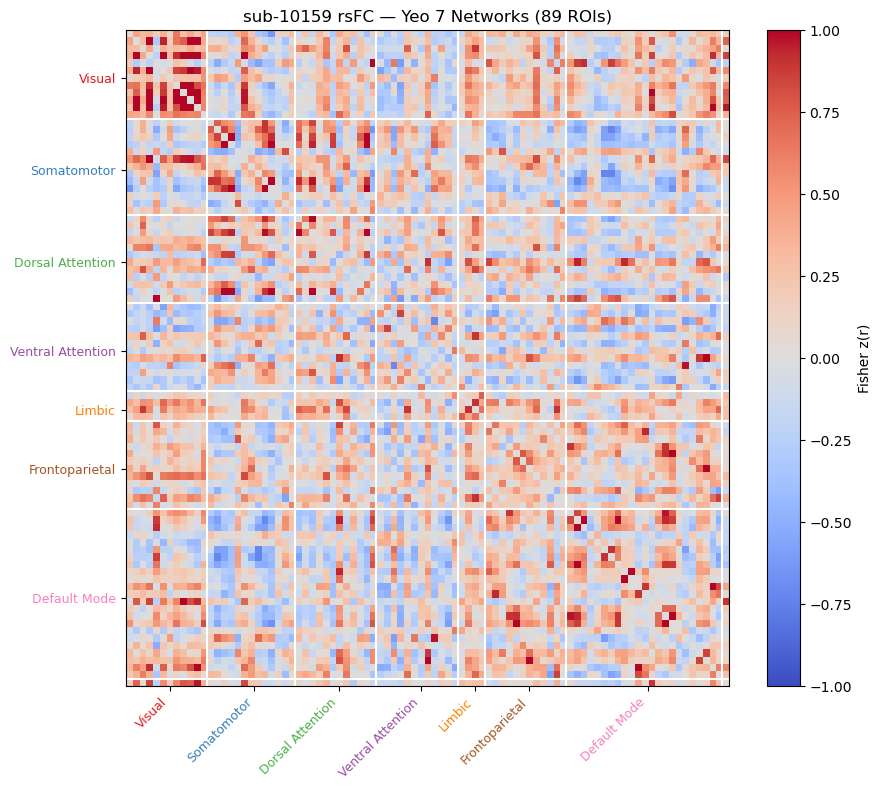

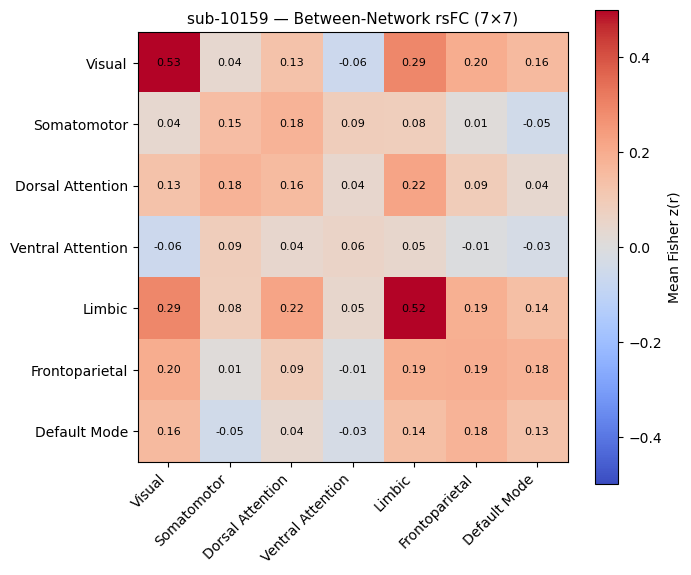

/var/folders/y2/55gml_617gzgft7wccv1y28h0000gp/T/ipykernel_59214/1815703579.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


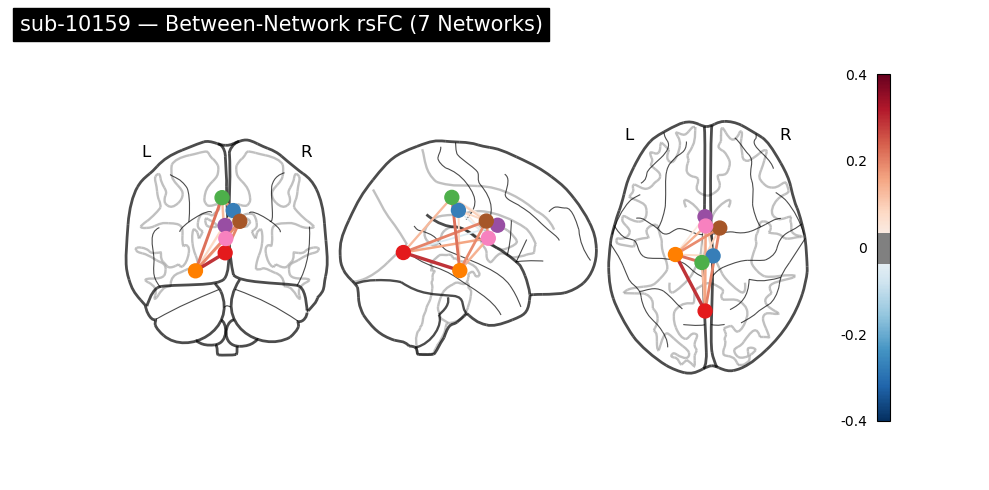

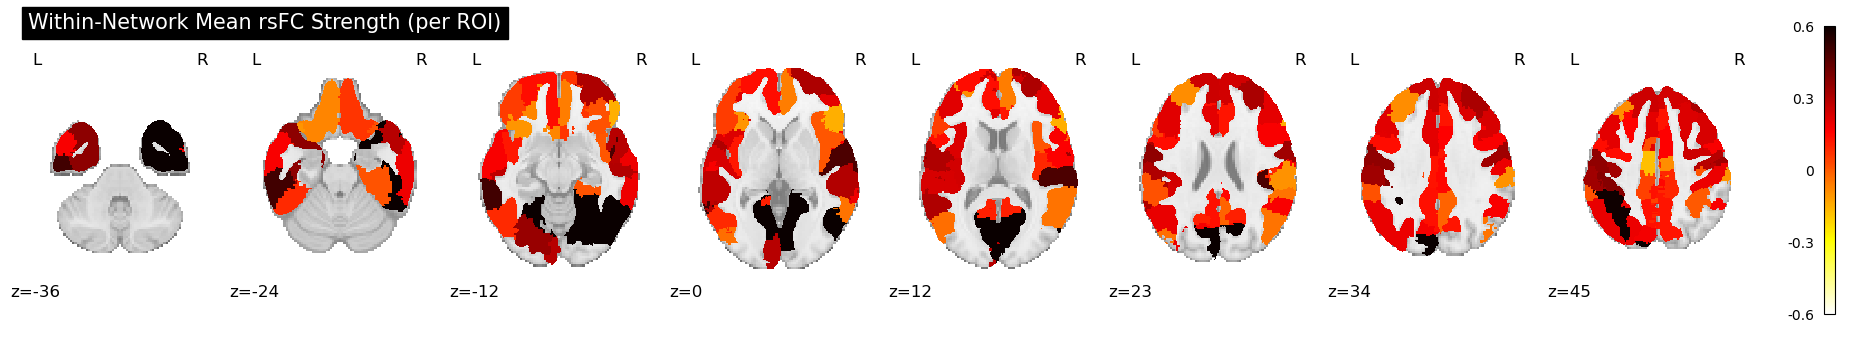

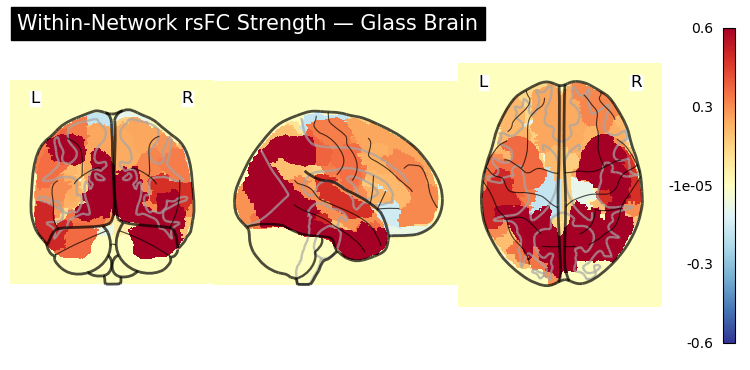

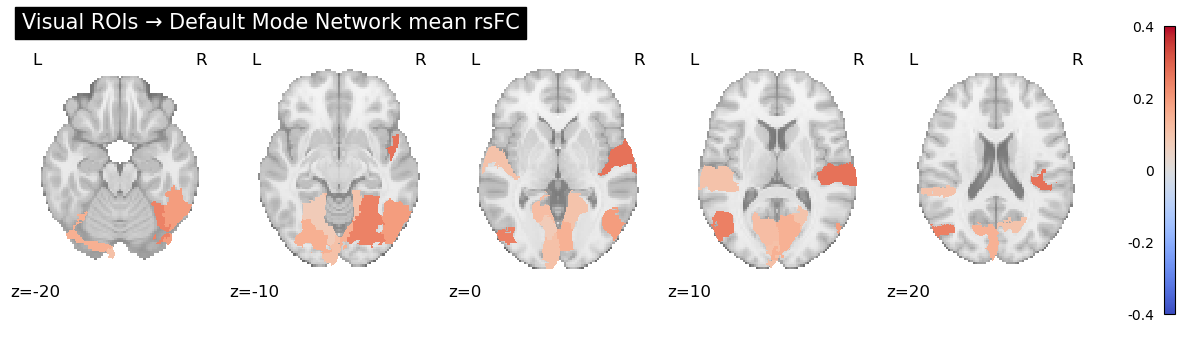

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker

# ── 1. ATLAS ──────────────────────────────────────────────────────────────────
atlas     = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = atlas.maps
atlas_img_loaded = nib.load(atlas_img) if isinstance(atlas_img, str) else atlas_img

# Decode labels; skip index 0 (Background)
atlas_labels_all = [l.decode() if isinstance(l, bytes) else l for l in atlas.labels]

# Build network names — only for real ROI labels (skip Background at index 0)
# atlas.labels corresponds to label values 1..N in the atlas volume
atlas_labels  = atlas_labels_all  # all 100 ROI labels (no background entry in atlas.labels)
network_names = []
for lbl in atlas_labels:
    parts = lbl.split("_")
    network_names.append(parts[2] if len(parts) > 2 else "Unknown")

# Diagnose any unexpected network names
for i, (lbl, net) in enumerate(zip(atlas_labels, network_names)):
    if net not in ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]:
        print(f"ROI {i}: '{lbl}' → parsed net: '{net}'")

unique_nets    = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
net_colors     = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf"]
net_label_full = {
    "Vis":         "Visual",
    "SomMot":      "Somatomotor",
    "DorsAttn":    "Dorsal Attention",
    "SalVentAttn": "Ventral Attention",
    "Limbic":      "Limbic",
    "Cont":        "Frontoparietal",
    "Default":     "Default Mode",
}

# ── 2. CONFOUNDS ──────────────────────────────────────────────────────────────
confounds = pd.read_csv(confounds_file, sep="\t")

candidate_confounds = [
    # 6 motion params — both fMRIPrep naming conventions
    "X","Y","Z","RotX","RotY","RotZ",
    "trans_x","trans_y","trans_z","rot_x","rot_y","rot_z",
    # motion derivatives (catch sharp spikes)
    "trans_x_derivative1","trans_y_derivative1","trans_z_derivative1",
    "rot_x_derivative1","rot_y_derivative1","rot_z_derivative1",
    # physiological noise
    "WhiteMatter","CSF",
    # anatomical CompCor (noise from WM/CSF regions)
    "aCompCor00","aCompCor01","aCompCor02",
    "aCompCor03","aCompCor04","aCompCor05",
    # spike regressors — NOTE: these have NaN at row 0, fillna(0) below is critical
    "FramewiseDisplacement","stdDVARS",
]

confound_cols  = [c for c in candidate_confounds if c in confounds.columns]
confounds_used = confounds[confound_cols].fillna(0)  # fillna critical for FD/DVARS row 0
print("Using confounds:", confound_cols)

# ── 3. MASKER ─────────────────────────────────────────────────────────────────
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    mask_img=mask_img,
    standardize="zscore_sample",   # z-score each ROI timeseries → equal amplitude
    detrend=True,                  # remove linear scanner drift
    low_pass=0.1,                  # remove high-freq noise (above 0.1 Hz)
    high_pass=0.01,                # remove slow drift (below 0.01 Hz)
    t_r=2.0,                       # ds000030 TR in seconds — required for bandpass
    resampling_target="data",      # resample atlas to match BOLD grid
    memory="nilearn_cache",
    verbose=1,
)
time_series = masker.fit_transform(bold_img, confounds=confounds_used)
print("Time series shape:", time_series.shape)  # expect (n_timepoints, 100)

# ── 4. DROP ZERO-VARIANCE ROIs ────────────────────────────────────────────────
stds      = time_series.std(axis=0)
good_mask = stds > 0.01
good_rois = np.where(good_mask)[0]
ts_clean  = time_series[:, good_rois]
names_clean  = [network_names[i] for i in good_rois]
labels_clean = [atlas_labels[i]  for i in good_rois]
print(f"Kept {len(good_rois)}/100 ROIs (dropped {100-len(good_rois)} zero-variance ROIs)")
print("Dropped networks:", [network_names[i] for i in np.where(~good_mask)[0]])

# ── 5. CORRELATION MATRIX ─────────────────────────────────────────────────────
corr   = np.corrcoef(ts_clean.T)
z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))
np.fill_diagonal(z_corr, 0)
print("NaNs in z_corr:", np.isnan(z_corr).sum())  # should be 0

# ── 6. SORT ROIs BY NETWORK ───────────────────────────────────────────────────
sort_idx    = sorted(range(len(labels_clean)),
                     key=lambda i: unique_nets.index(names_clean[i])
                     if names_clean[i] in unique_nets else 99)
z_sorted    = z_corr[np.ix_(sort_idx, sort_idx)]
nets_sorted = [names_clean[i] for i in sort_idx]

boundaries = [0]
prev = None
for i, n in enumerate(nets_sorted):
    if n != prev and prev is not None:
        boundaries.append(i)
    prev = n
boundaries.append(len(nets_sorted))

ticks, tick_labels, tick_colors = [], [], []
for k in range(len(boundaries)-1):
    net = nets_sorted[boundaries[k]]
    if net not in unique_nets:
        continue
    ticks.append((boundaries[k] + boundaries[k+1]) / 2)
    tick_labels.append(net_label_full.get(net, net))
    tick_colors.append(net_colors[unique_nets.index(net)])

# ── 7. PLOT: 89×89 MATRIX ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(z_sorted, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
plt.colorbar(im, ax=ax, label="Fisher z(r)")

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", lw=1.5)
    ax.axvline(b - 0.5, color="white", lw=1.5)

ax.set_xticks(ticks); ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(ticks); ax.set_yticklabels(tick_labels, fontsize=9)
for tick, col in zip(ax.get_xticklabels(), tick_colors): tick.set_color(col)
for tick, col in zip(ax.get_yticklabels(), tick_colors): tick.set_color(col)
ax.set_title(f"sub-10159 rsFC — Yeo 7 Networks ({len(good_rois)} ROIs)", fontsize=12)
plt.tight_layout(); plt.show()

# ── 8. PLOT: 7×7 SUMMARY MATRIX ──────────────────────────────────────────────
n_nets = len(unique_nets)
net7   = np.zeros((n_nets, n_nets))

for i, ni in enumerate(unique_nets):
    for j, nj in enumerate(unique_nets):
        idx_i = [k for k, n in enumerate(names_clean) if n == ni]
        idx_j = [k for k, n in enumerate(names_clean) if n == nj]
        if idx_i and idx_j:
            block = z_corr[np.ix_(idx_i, idx_j)]
            if i == j:
                vals = block[np.triu_indices(len(idx_i), k=1)]  # upper triangle, no diagonal
            else:
                vals = block.flatten()
            net7[i, j] = vals.mean() if len(vals) > 0 else 0

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(net7, vmin=-0.5, vmax=0.5, cmap="coolwarm")
plt.colorbar(im, ax=ax, label="Mean Fisher z(r)")
full_names = [net_label_full[n] for n in unique_nets]
ax.set_xticks(range(n_nets)); ax.set_xticklabels(full_names, rotation=45, ha="right")
ax.set_yticks(range(n_nets)); ax.set_yticklabels(full_names)
for i in range(n_nets):
    for j in range(n_nets):
        ax.text(j, i, f"{net7[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("sub-10159 — Between-Network rsFC (7×7)", fontsize=11)
plt.tight_layout(); plt.show()

# ── 9. PLOT: BETWEEN-NETWORK CONNECTOME (width = connection strength) ─────────
from nilearn import plotting as nlplot
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get centroid coordinates for each network (average of ROI centroids)
# First get ROI centroids from the atlas
from nilearn.image import get_data
atlas_data = atlas_img_loaded.get_fdata()

def get_roi_centroid(atlas_data, label_val, affine):
    """Get MNI centroid of a given atlas label value."""
    vox = np.array(np.where(atlas_data == label_val)).T
    if len(vox) == 0:
        return None
    vox_mean = vox.mean(axis=0)
    mni = nib.affines.apply_affine(affine, vox_mean)
    return mni

# Compute network centroids (average of ROI centroids within each network)
net_centroids = {}
for net in unique_nets:
    roi_indices = [i for i, n in enumerate(names_clean) if n == net]
    centroids = []
    for roi_rank in roi_indices:
        roi_orig  = good_rois[roi_rank]
        label_val = roi_orig + 1  # atlas labels are 1-indexed
        c = get_roi_centroid(atlas_data, label_val, atlas_img_loaded.affine)
        if c is not None:
            centroids.append(c)
    if centroids:
        net_centroids[net] = np.mean(centroids, axis=0)

# Build node/edge arrays for the connectome plot
node_coords = np.array([net_centroids[n] for n in unique_nets if n in net_centroids])
valid_nets   = [n for n in unique_nets if n in net_centroids]
node_colors  = [net_colors[unique_nets.index(n)] for n in valid_nets]
node_size    = 100

n_valid = len(valid_nets)
adjacency = np.zeros((n_valid, n_valid))
for i, ni in enumerate(valid_nets):
    for j, nj in enumerate(valid_nets):
        if i != j:
            adjacency[i, j] = net7[unique_nets.index(ni), unique_nets.index(nj)]

# plot_connectome uses edge_threshold to filter weak edges
# edge width is controlled by the magnitude in adjacency
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
display = nlplot.plot_connectome(
    adjacency,
    node_coords,
    node_color=node_colors,
    node_size=node_size,
    edge_cmap="RdBu_r",
    edge_vmin=-0.4,
    edge_vmax=0.4,
    edge_threshold="20%",   # only show top 80% of connections by absolute strength
    colorbar=True,
    title="sub-10159 — Between-Network rsFC (7 Networks)",
    axes=ax,
    black_bg=False,
)
plt.tight_layout()
plt.show()

# ── 10. PLOT: WITHIN-NETWORK STRENGTH ON BRAIN (FIXED) ───────────────────────
atlas_data   = atlas_img_loaded.get_fdata()
strength_vol = np.zeros(atlas_data.shape)

for roi_rank, roi_orig in enumerate(good_rois):
    net = names_clean[roi_rank]
    same_net_idx = [k for k, n in enumerate(names_clean)
                    if n == net and k != roi_rank]
    mean_strength = z_corr[roi_rank, same_net_idx].mean() if same_net_idx else 0.0
    voxel_label   = roi_orig + 1   # atlas is 1-indexed
    strength_vol[atlas_data == voxel_label] = mean_strength

strength_img = nib.Nifti1Image(strength_vol, atlas_img_loaded.affine, atlas_img_loaded.header)

# Axial slices — hot_r colormap: yellow=low, red=mid, black=highest
plotting.plot_stat_map(
    strength_img,
    display_mode="z",
    cut_coords=8,
    colorbar=True,
    title="Within-Network Mean rsFC Strength (per ROI)",
    cmap="hot_r",
    vmax=0.6,
    black_bg=False,
)
plt.show()

# Glass brain — fixed: white background, diverging colormap so zero=white
plotting.plot_glass_brain(
    strength_img,
    colorbar=True,
    title="Within-Network rsFC Strength — Glass Brain",
    cmap="RdYlBu_r",   # diverging: blue=negative, white=0, red=positive
    vmax=0.6,
    vmin=-0.6,
    plot_abs=False,
    black_bg=False,     # white background
)
plt.show()

# ── HELPER: Between-network map for any pair ──────────────────────────────────
def make_between_net_img(source_net, target_net):
    """
    For each ROI in source_net, compute its mean z(r) to all ROIs in target_net.
    Returns a Nifti1Image with those values painted on the atlas volume.
    """
    vol = np.zeros(atlas_data.shape)
    for roi_rank, roi_orig in enumerate(good_rois):
        if names_clean[roi_rank] != source_net:
            continue
        target_idx = [k for k, n in enumerate(names_clean) if n == target_net]
        mean_conn  = z_corr[roi_rank, target_idx].mean() if target_idx else 0.0
        vol[atlas_data == roi_orig + 1] = mean_conn
    return nib.Nifti1Image(vol, atlas_img_loaded.affine, atlas_img_loaded.header)

# Example: Visual ↔ Default Mode (expect mild anticorrelation in healthy subjects)
vis_dmn_img = make_between_net_img("Vis", "Default")
plotting.plot_stat_map(
    vis_dmn_img,
    display_mode="z",
    cut_coords=[-20, -10, 0, 10, 20],
    colorbar=True,
    title="Visual ROIs → Default Mode Network mean rsFC",
    cmap="coolwarm",
    vmax=0.4,
    vmin=-0.4,
    black_bg=False,
)
plt.show()

# Running Pipeline on multiple participants

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker



## 0. Subject(s) identification

base_dir = "/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep"
sub = ["sub-10159", "sub-10171", "sub-10189"], # Healthy Participants
["sub-6001", "sub-60005", "sub-60006"]     #Bipolar participants

func_dir = os.path.join(base_dir, sub, "func")

bold_file      = os.path.join(func_dir, f"{sub}_task-rest_bold_space-T1w_preproc.nii.gz")
mask_file      = os.path.join(func_dir, f"{sub}_task-rest_bold_space-T1w_brainmask.nii.gz")
confounds_file = os.path.join(func_dir, f"{sub}_task-rest_bold_confounds.tsv")

import nibabel as nib
bold_img = nib.load(bold_file)         # ← This is what the masker receives
mask_img = nib.load(mask_file)         # ← Passed to NiftiLabelsMasker




# ── 1. ATLAS ──────────────────────────────────────────────────────────────────
atlas     = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = atlas.maps
atlas_img_loaded = nib.load(atlas_img) if isinstance(atlas_img, str) else atlas_img

# Decode labels; skip index 0 (Background)
atlas_labels_all = [l.decode() if isinstance(l, bytes) else l for l in atlas.labels]

# Build network names — only for real ROI labels (skip Background at index 0)
# atlas.labels corresponds to label values 1..N in the atlas volume
atlas_labels  = atlas_labels_all  # all 100 ROI labels (no background entry in atlas.labels)
network_names = []
for lbl in atlas_labels:
    parts = lbl.split("_")
    network_names.append(parts[2] if len(parts) > 2 else "Unknown")

# Diagnose any unexpected network names
for i, (lbl, net) in enumerate(zip(atlas_labels, network_names)):
    if net not in ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]:
        print(f"ROI {i}: '{lbl}' → parsed net: '{net}'")

unique_nets    = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
net_colors     = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf"]
net_label_full = {
    "Vis":         "Visual",
    "SomMot":      "Somatomotor",
    "DorsAttn":    "Dorsal Attention",
    "SalVentAttn": "Ventral Attention",
    "Limbic":      "Limbic",
    "Cont":        "Frontoparietal",
    "Default":     "Default Mode",
}

# ── 2. CONFOUNDS ──────────────────────────────────────────────────────────────
confounds = pd.read_csv(confounds_file, sep="\t")

candidate_confounds = [
    # 6 motion params — both fMRIPrep naming conventions
    "X","Y","Z","RotX","RotY","RotZ",
    "trans_x","trans_y","trans_z","rot_x","rot_y","rot_z",
    # motion derivatives (catch sharp spikes)
    "trans_x_derivative1","trans_y_derivative1","trans_z_derivative1",
    "rot_x_derivative1","rot_y_derivative1","rot_z_derivative1",
    # physiological noise
    "WhiteMatter","CSF",
    # anatomical CompCor (noise from WM/CSF regions)
    "aCompCor00","aCompCor01","aCompCor02",
    "aCompCor03","aCompCor04","aCompCor05",
    # spike regressors — NOTE: these have NaN at row 0, fillna(0) below is critical
    "FramewiseDisplacement","stdDVARS",
]

confound_cols  = [c for c in candidate_confounds if c in confounds.columns]
confounds_used = confounds[confound_cols].fillna(0)  # fillna critical for FD/DVARS row 0
print("Using confounds:", confound_cols)

# ── 2b. MEAN FD QUALITY CHECK ────────────────────────────────────────────────
MEAN_FD_THRESHOLD = 0.5  # mm — exclude subject if average motion exceeds this

if "FramewiseDisplacement" in confounds.columns:
    # Row 0 is NaN (FD is a difference score); skip it for the mean
    mean_fd = confounds["FramewiseDisplacement"].iloc[1:].mean()
    print(f"{sub} mean FD: {mean_fd:.3f} mm")
    
    if mean_fd > MEAN_FD_THRESHOLD:
        print(f"⚠️  {sub} EXCLUDED — mean FD {mean_fd:.3f} mm exceeds threshold {MEAN_FD_THRESHOLD} mm")
        raise ValueError(f"Subject {sub} excluded due to excessive motion.")
    else:
        print(f"✅ {sub} passes motion QC")
else:
    print("⚠️  FramewiseDisplacement not found in confounds — skipping FD check")


# ── 2c. OPTIONAL TR-LEVEL SCRUBBING ──────────────────────────────────────────
FD_SPIKE_THRESHOLD = 0.5   # censor any TR where FD > this

if "FramewiseDisplacement" in confounds.columns:
    fd_series = confounds["FramewiseDisplacement"].fillna(0)
    spike_mask = fd_series > FD_SPIKE_THRESHOLD
    n_censored = spike_mask.sum()
    pct_censored = n_censored / len(fd_series) * 100
    print(f"  TRs censored (FD > {FD_SPIKE_THRESHOLD} mm): {n_censored} / {len(fd_series)} ({pct_censored:.1f}%)")
    
    # Add a spike regressor column per censored TR
    for tr_idx in np.where(spike_mask)[0]:
        col = np.zeros(len(confounds))
        col[tr_idx] = 1
        confounds_used[f"scrub_tr{tr_idx}"] = col
    # The masker will partial out these TRs from the signal
    

# ── 3. MASKER ─────────────────────────────────────────────────────────────────
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    mask_img=mask_img,
    standardize="zscore_sample",   # z-score each ROI timeseries → equal amplitude
    detrend=True,                  # remove linear scanner drift
    low_pass=0.1,                  # remove high-freq noise (above 0.1 Hz)
    high_pass=0.01,                # remove slow drift (below 0.01 Hz)
    t_r=2.0,                       # ds000030 TR in seconds — required for bandpass
    resampling_target="data",      # resample atlas to match BOLD grid
    memory="nilearn_cache",
    verbose=1,
)
time_series = masker.fit_transform(bold_img, confounds=confounds_used)
print("Time series shape:", time_series.shape)  # expect (n_timepoints, 100)

# ── 4. DROP ZERO-VARIANCE ROIs ────────────────────────────────────────────────
stds      = time_series.std(axis=0)
good_mask = stds > 0.01
good_rois = np.where(good_mask)[0]
ts_clean  = time_series[:, good_rois]
names_clean  = [network_names[i] for i in good_rois]
labels_clean = [atlas_labels[i]  for i in good_rois]
print(f"Kept {len(good_rois)}/100 ROIs (dropped {100-len(good_rois)} zero-variance ROIs)")
print("Dropped networks:", [network_names[i] for i in np.where(~good_mask)[0]])

# ── 5. CORRELATION MATRIX ─────────────────────────────────────────────────────
corr   = np.corrcoef(ts_clean.T)
z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))
np.fill_diagonal(z_corr, 0)
print("NaNs in z_corr:", np.isnan(z_corr).sum())  # should be 0

# ── 6. SORT ROIs BY NETWORK ───────────────────────────────────────────────────
sort_idx    = sorted(range(len(labels_clean)),
                     key=lambda i: unique_nets.index(names_clean[i])
                     if names_clean[i] in unique_nets else 99)
z_sorted    = z_corr[np.ix_(sort_idx, sort_idx)]
nets_sorted = [names_clean[i] for i in sort_idx]

boundaries = [0]
prev = None
for i, n in enumerate(nets_sorted):
    if n != prev and prev is not None:
        boundaries.append(i)
    prev = n
boundaries.append(len(nets_sorted))

ticks, tick_labels, tick_colors = [], [], []
for k in range(len(boundaries)-1):
    net = nets_sorted[boundaries[k]]
    if net not in unique_nets:
        continue
    ticks.append((boundaries[k] + boundaries[k+1]) / 2)
    tick_labels.append(net_label_full.get(net, net))
    tick_colors.append(net_colors[unique_nets.index(net)])

# ── 7. PLOT: 89×89 MATRIX ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(z_sorted, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
plt.colorbar(im, ax=ax, label="Fisher z(r)")

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", lw=1.5)
    ax.axvline(b - 0.5, color="white", lw=1.5)

ax.set_xticks(ticks); ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(ticks); ax.set_yticklabels(tick_labels, fontsize=9)
for tick, col in zip(ax.get_xticklabels(), tick_colors): tick.set_color(col)
for tick, col in zip(ax.get_yticklabels(), tick_colors): tick.set_color(col)
ax.set_title(f"sub-10159 rsFC — Yeo 7 Networks ({len(good_rois)} ROIs)", fontsize=12)
plt.tight_layout(); plt.show()

# ── 8. PLOT: 7×7 SUMMARY MATRIX ──────────────────────────────────────────────
n_nets = len(unique_nets)
net7   = np.zeros((n_nets, n_nets))

for i, ni in enumerate(unique_nets):
    for j, nj in enumerate(unique_nets):
        idx_i = [k for k, n in enumerate(names_clean) if n == ni]
        idx_j = [k for k, n in enumerate(names_clean) if n == nj]
        if idx_i and idx_j:
            block = z_corr[np.ix_(idx_i, idx_j)]
            if i == j:
                vals = block[np.triu_indices(len(idx_i), k=1)]  # upper triangle, no diagonal
            else:
                vals = block.flatten()
            net7[i, j] = vals.mean() if len(vals) > 0 else 0

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(net7, vmin=-0.5, vmax=0.5, cmap="coolwarm")
plt.colorbar(im, ax=ax, label="Mean Fisher z(r)")
full_names = [net_label_full[n] for n in unique_nets]
ax.set_xticks(range(n_nets)); ax.set_xticklabels(full_names, rotation=45, ha="right")
ax.set_yticks(range(n_nets)); ax.set_yticklabels(full_names)
for i in range(n_nets):
    for j in range(n_nets):
        ax.text(j, i, f"{net7[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("sub-10159 — Between-Network rsFC (7×7)", fontsize=11)
plt.tight_layout(); plt.show()

# ── 9. PLOT: BETWEEN-NETWORK CONNECTOME (width = connection strength) ─────────
from nilearn import plotting as nlplot
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get centroid coordinates for each network (average of ROI centroids)
# First get ROI centroids from the atlas
from nilearn.image import get_data
atlas_data = atlas_img_loaded.get_fdata()

def get_roi_centroid(atlas_data, label_val, affine):
    """Get MNI centroid of a given atlas label value."""
    vox = np.array(np.where(atlas_data == label_val)).T
    if len(vox) == 0:
        return None
    vox_mean = vox.mean(axis=0)
    mni = nib.affines.apply_affine(affine, vox_mean)
    return mni

# Compute network centroids (average of ROI centroids within each network)
net_centroids = {}
for net in unique_nets:
    roi_indices = [i for i, n in enumerate(names_clean) if n == net]
    centroids = []
    for roi_rank in roi_indices:
        roi_orig  = good_rois[roi_rank]
        label_val = roi_orig + 1  # atlas labels are 1-indexed
        c = get_roi_centroid(atlas_data, label_val, atlas_img_loaded.affine)
        if c is not None:
            centroids.append(c)
    if centroids:
        net_centroids[net] = np.mean(centroids, axis=0)

# Build node/edge arrays for the connectome plot
node_coords = np.array([net_centroids[n] for n in unique_nets if n in net_centroids])
valid_nets   = [n for n in unique_nets if n in net_centroids]
node_colors  = [net_colors[unique_nets.index(n)] for n in valid_nets]
node_size    = 100

n_valid = len(valid_nets)
adjacency = np.zeros((n_valid, n_valid))
for i, ni in enumerate(valid_nets):
    for j, nj in enumerate(valid_nets):
        if i != j:
            adjacency[i, j] = net7[unique_nets.index(ni), unique_nets.index(nj)]

# plot_connectome uses edge_threshold to filter weak edges
# edge width is controlled by the magnitude in adjacency
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
display = nlplot.plot_connectome(
    adjacency,
    node_coords,
    node_color=node_colors,
    node_size=node_size,
    edge_cmap="RdBu_r",
    edge_vmin=-0.4,
    edge_vmax=0.4,
    edge_threshold="20%",   # only show top 80% of connections by absolute strength
    colorbar=True,
    title="sub-10159 — Between-Network rsFC (7 Networks)",
    axes=ax,
    black_bg=False,
)
plt.tight_layout()
plt.show()

# ── 10. PLOT: WITHIN-NETWORK STRENGTH ON BRAIN (FIXED) ───────────────────────
atlas_data   = atlas_img_loaded.get_fdata()
strength_vol = np.zeros(atlas_data.shape)

for roi_rank, roi_orig in enumerate(good_rois):
    net = names_clean[roi_rank]
    same_net_idx = [k for k, n in enumerate(names_clean)
                    if n == net and k != roi_rank]
    mean_strength = z_corr[roi_rank, same_net_idx].mean() if same_net_idx else 0.0
    voxel_label   = roi_orig + 1   # atlas is 1-indexed
    strength_vol[atlas_data == voxel_label] = mean_strength

strength_img = nib.Nifti1Image(strength_vol, atlas_img_loaded.affine, atlas_img_loaded.header)

# Axial slices — hot_r colormap: yellow=low, red=mid, black=highest
plotting.plot_stat_map(
    strength_img,
    display_mode="z",
    cut_coords=8,
    colorbar=True,
    title="Within-Network Mean rsFC Strength (per ROI)",
    cmap="hot_r",
    vmax=0.6,
    black_bg=False,
)
plt.show()

# Glass brain — fixed: white background, diverging colormap so zero=white
plotting.plot_glass_brain(
    strength_img,
    colorbar=True,
    title="Within-Network rsFC Strength — Glass Brain",
    cmap="RdYlBu_r",   # diverging: blue=negative, white=0, red=positive
    vmax=0.6,
    vmin=-0.6,
    plot_abs=False,
    black_bg=False,     # white background
)
plt.show()

# ── HELPER: Between-network map for any pair ──────────────────────────────────
def make_between_net_img(source_net, target_net):
    """
    For each ROI in source_net, compute its mean z(r) to all ROIs in target_net.
    Returns a Nifti1Image with those values painted on the atlas volume.
    """
    vol = np.zeros(atlas_data.shape)
    for roi_rank, roi_orig in enumerate(good_rois):
        if names_clean[roi_rank] != source_net:
            continue
        target_idx = [k for k, n in enumerate(names_clean) if n == target_net]
        mean_conn  = z_corr[roi_rank, target_idx].mean() if target_idx else 0.0
        vol[atlas_data == roi_orig + 1] = mean_conn
    return nib.Nifti1Image(vol, atlas_img_loaded.affine, atlas_img_loaded.header)

# Example: Visual ↔ Default Mode (expect mild anticorrelation in healthy subjects)
vis_dmn_img = make_between_net_img("Vis", "Default")
plotting.plot_stat_map(
    vis_dmn_img,
    display_mode="z",
    cut_coords=[-20, -10, 0, 10, 20],
    colorbar=True,
    title="Visual ROIs → Default Mode Network mean rsFC",
    cmap="coolwarm",
    vmax=0.4,
    vmin=-0.4,
    black_bg=False,
)
plt.show()

## improved pipeline

In [48]:
# Block 0: subjects
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker

# ── 0. SUBJECT REGISTRY ───────────────────────────────────────────────────────
base_dir = "/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep"

subject_registry = {
    "HC":  ["sub-10159", "sub-10171", "sub-10189"],   # Healthy Controls
    "BD":  ["sub-60010", "sub-60011", "sub-60012", "sub-60014"],   # Bipolar Disorder
}

# Flat list + label lookup — used throughout the loop
all_subjects = []
subject_labels = {}   # sub_id → "HC" or "BD"
for group, subs in subject_registry.items():
    for s in subs:
        all_subjects.append(s)
        subject_labels[s] = group

print("Subjects registered:")
for sub, grp in subject_labels.items():
    print(f"  {sub}  [{grp}]")

Subjects registered:
  sub-10159  [HC]
  sub-10171  [HC]
  sub-10189  [HC]
  sub-60010  [BD]
  sub-60011  [BD]
  sub-60012  [BD]
  sub-60014  [BD]


In [49]:
# Block 1: Atlas

# ── 1. ATLAS ─────────────────────────────────────────────────────────────────
atlas            = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img        = atlas.maps
atlas_img_loaded = nib.load(atlas_img) if isinstance(atlas_img, str) else atlas_img
atlas_data       = atlas_img_loaded.get_fdata()   # reused in every subject loop

atlas_labels = [l.decode() if isinstance(l, bytes) else l for l in atlas.labels]
network_names = []
for lbl in atlas_labels:
    parts = lbl.split("_")
    network_names.append(parts[2] if len(parts) > 2 else "Unknown")

unique_nets    = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
net_colors     = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf"]
net_label_full = {
    "Vis": "Visual", "SomMot": "Somatomotor", "DorsAttn": "Dorsal Attention",
    "SalVentAttn": "Ventral Attention", "Limbic": "Limbic",
    "Cont": "Frontoparietal", "Default": "Default Mode",
}

MEAN_FD_THRESHOLD  = 0.5   # mm — whole-subject exclusion
FD_SPIKE_THRESHOLD = 0.5   # mm — TR-level scrubbing

# Storage for group-level analysis
results = {}   # sub_id → {"group", "net7", "good_rois", "names_clean",
               #            "z_corr", "mean_fd", "passed_qc"}

[fetch_atlas_schaefer_2018] Dataset found in /Users/leilanytorresdiaz/nilearn_data/schaefer_2018


  Processing sub-10159  [HC]
  Mean FD: 0.152 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 5/152 (3.3%)
  Time series shape: (152, 100)
  Kept 89/100 ROIs


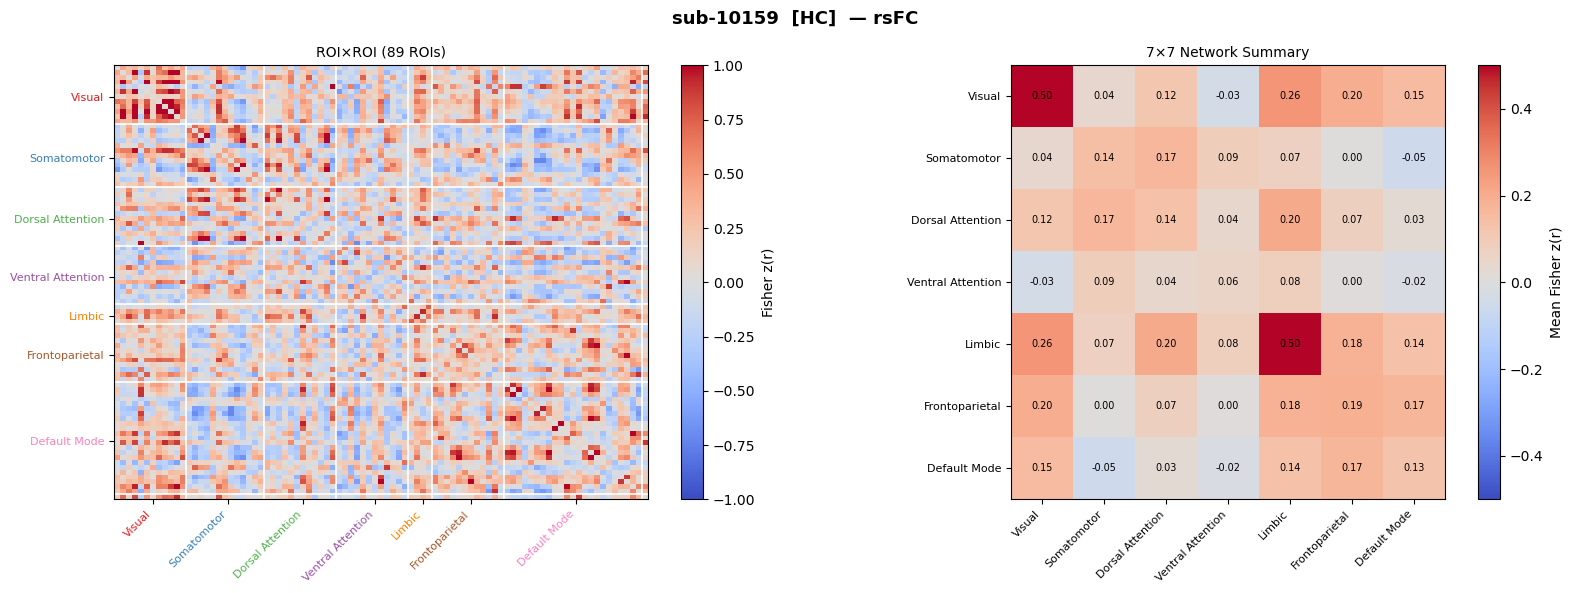


  Processing sub-10171  [HC]
  Mean FD: 0.369 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 32/152 (21.1%)
  Time series shape: (152, 100)
  Kept 99/100 ROIs


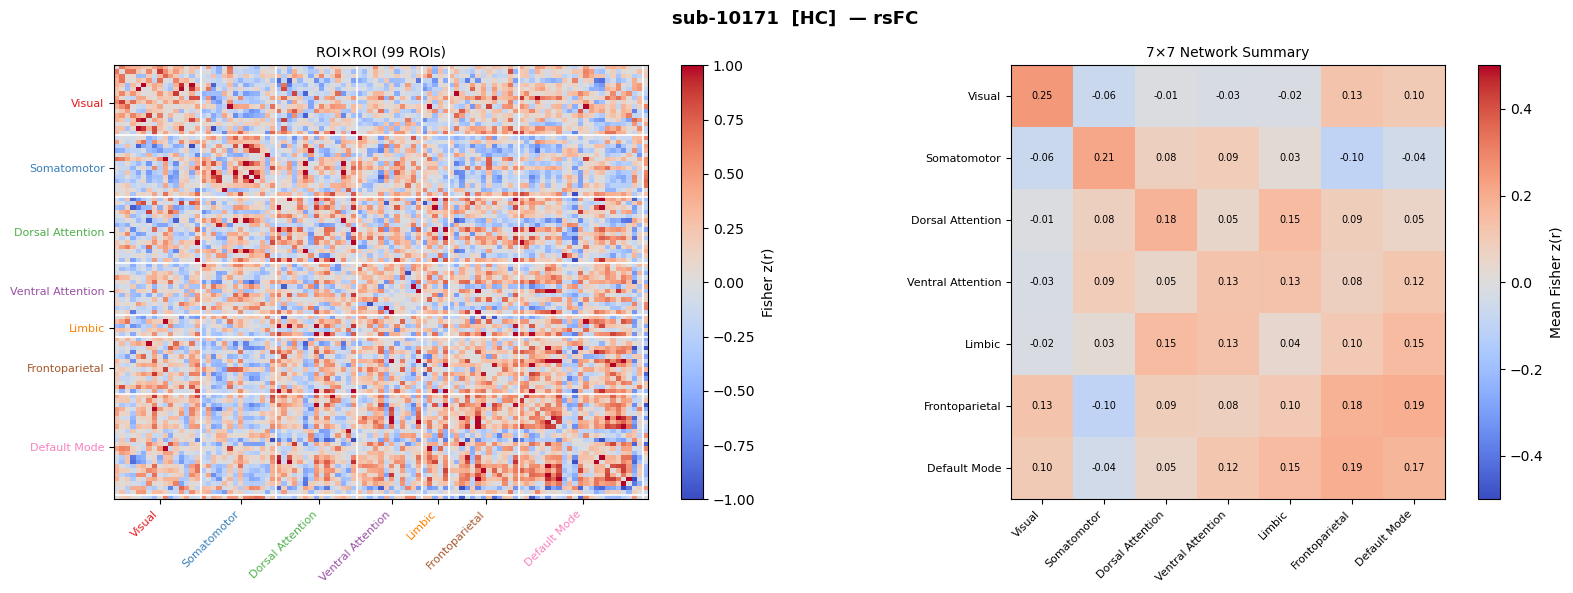


  Processing sub-10189  [HC]
  Mean FD: 0.188 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 7/152 (4.6%)
  Time series shape: (152, 100)
  Kept 99/100 ROIs


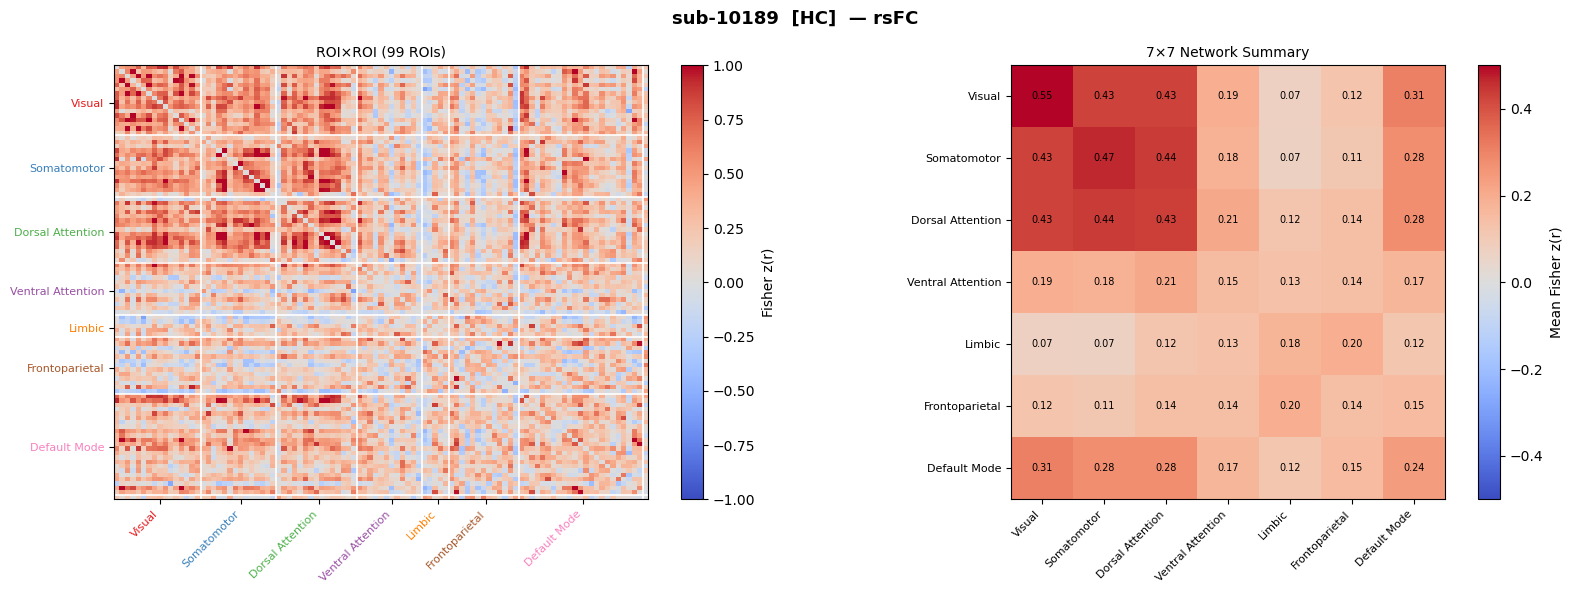


  Processing sub-60010  [BD]
  Mean FD: 0.276 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 22/152 (14.5%)


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 98/100 ROIs


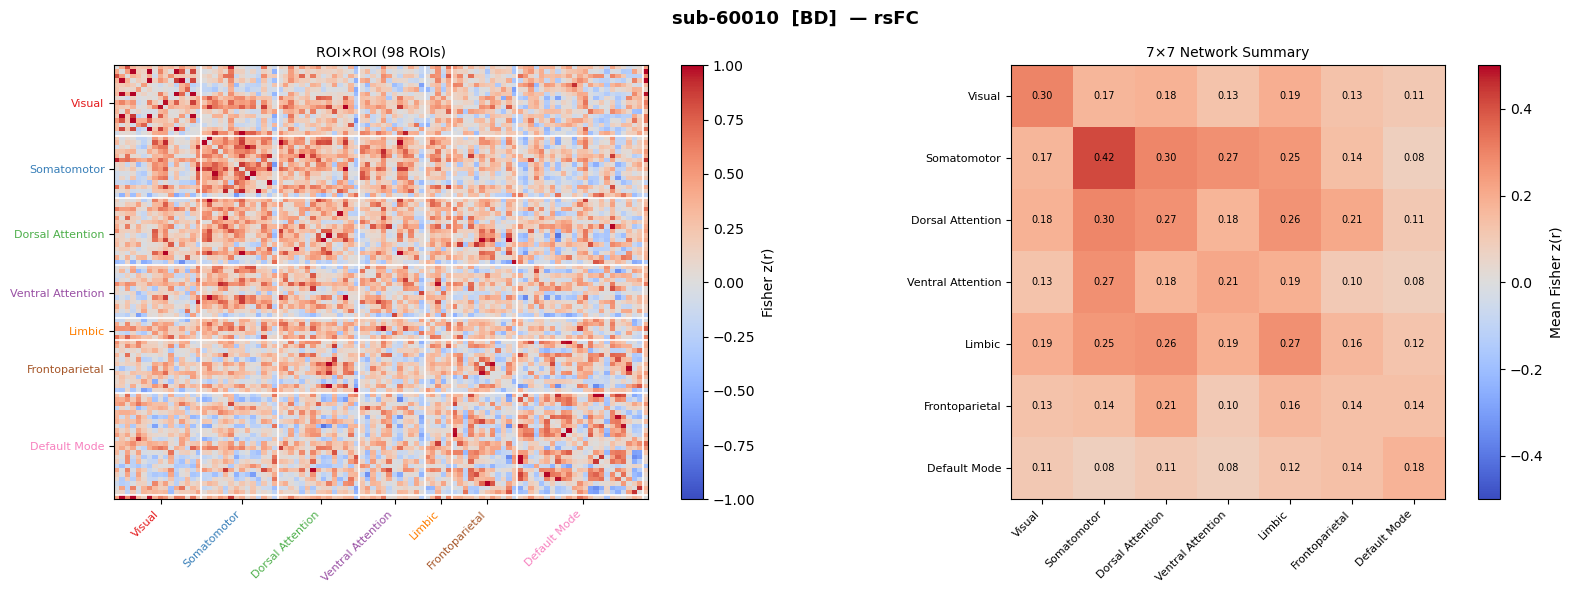


  Processing sub-60011  [BD]
  Mean FD: 0.077 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 1/152 (0.7%)


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 98/100 ROIs


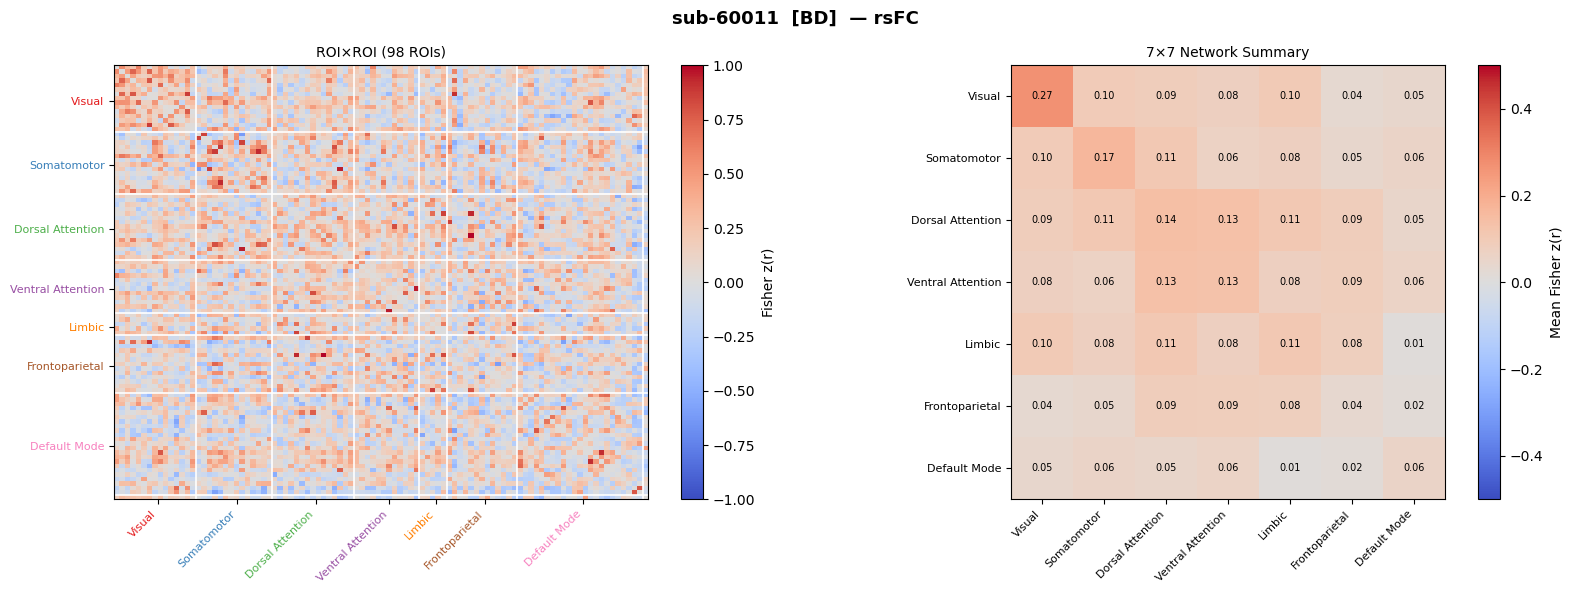


  Processing sub-60012  [BD]
  Mean FD: 0.055 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 0/152 (0.0%)


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 98/100 ROIs


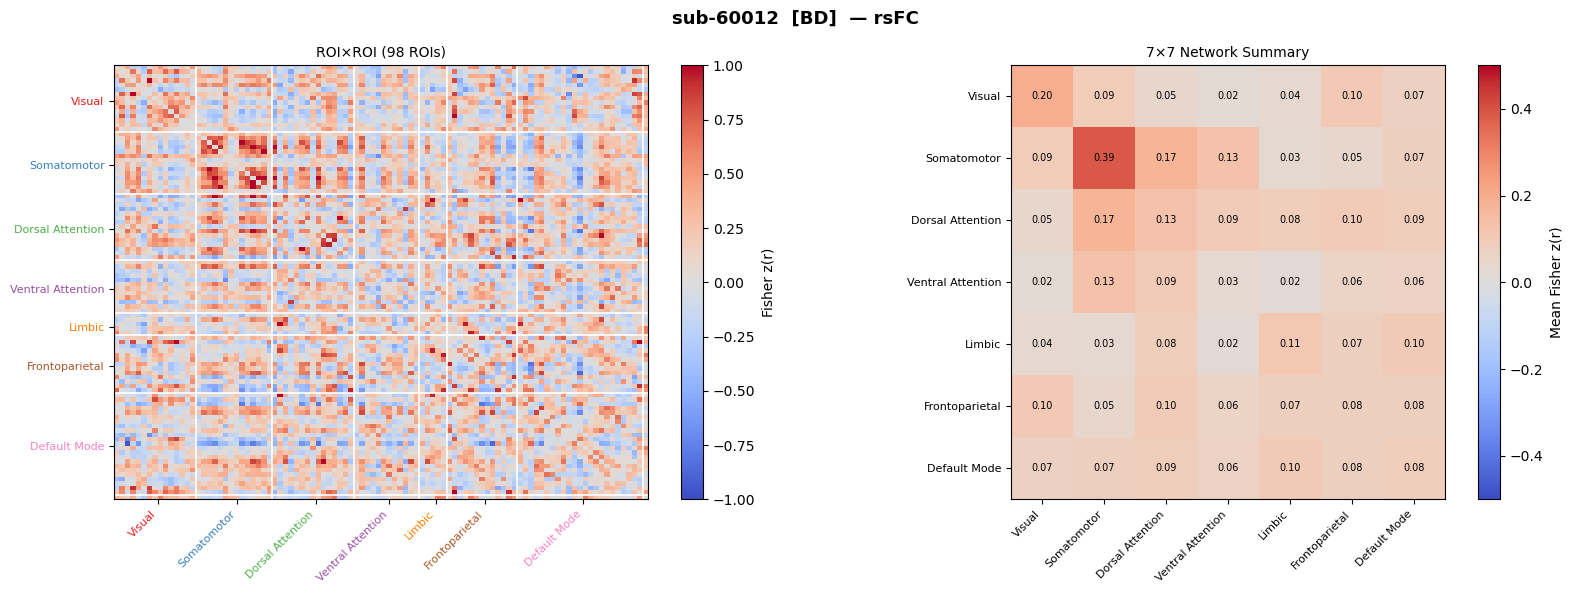


  Processing sub-60014  [BD]
  Mean FD: 0.277 mm
  ✅ Passes motion QC
  TRs censored (FD > 0.5 mm): 5/152 (3.3%)


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 94/100 ROIs


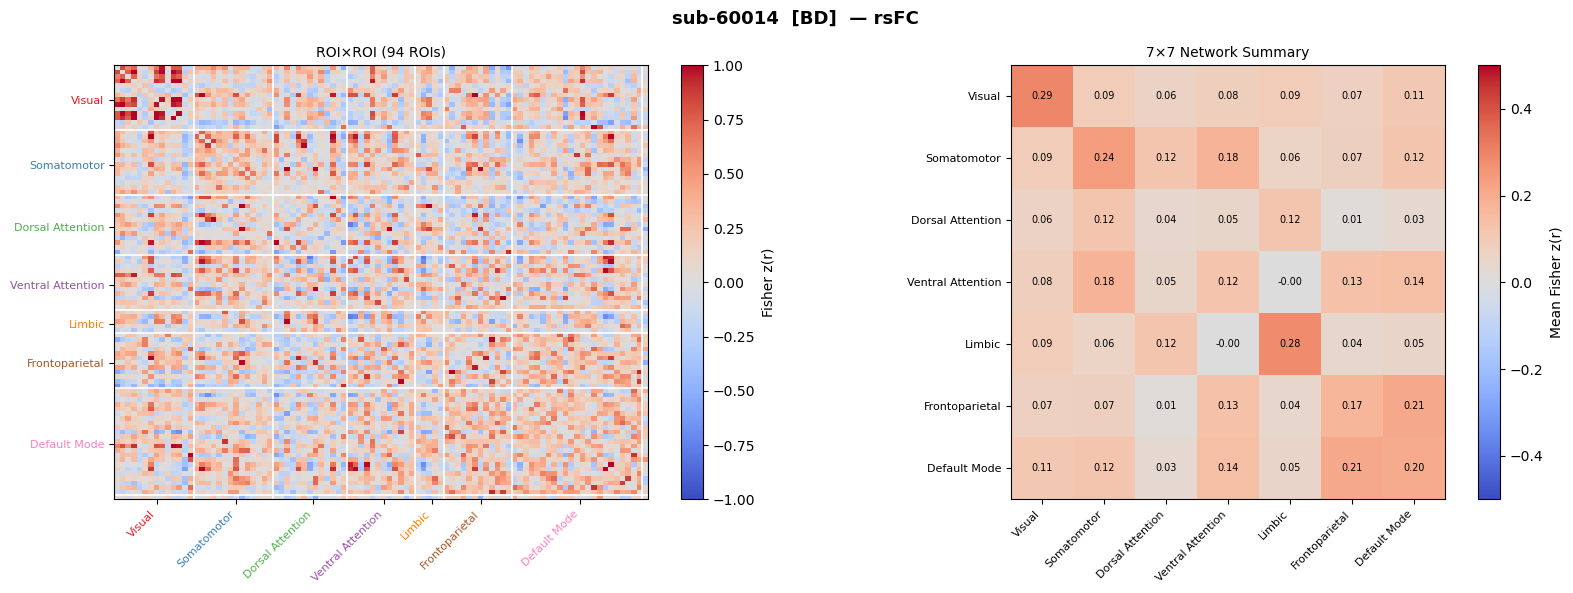


✅ Loop complete.
Passed QC: ['sub-10159', 'sub-10171', 'sub-10189', 'sub-60010', 'sub-60011', 'sub-60012', 'sub-60014']
Excluded:  []


In [51]:
# Block 2: per subject Loop

# ── 2. MAIN SUBJECT LOOP ──────────────────────────────────────────────────────
for sub in all_subjects:
    group = subject_labels[sub]
    print(f"\n{'='*60}")
    print(f"  Processing {sub}  [{group}]")
    print(f"{'='*60}")

    # ── File paths (all derived from sub) ─────────────────────────────────────
    func_dir       = os.path.join(base_dir, sub, "func")
    bold_file      = os.path.join(func_dir, f"{sub}_task-rest_bold_space-T1w_preproc.nii.gz")
    mask_file      = os.path.join(func_dir, f"{sub}_task-rest_bold_space-T1w_brainmask.nii.gz")
    confounds_file = os.path.join(func_dir, f"{sub}_task-rest_bold_confounds.tsv")

    # ── Load images ───────────────────────────────────────────────────────────
    bold_img = nib.load(bold_file)
    mask_img = nib.load(mask_file)

    # ── Confounds ─────────────────────────────────────────────────────────────
    confounds = pd.read_csv(confounds_file, sep="\t")

    candidate_confounds = [
        "X","Y","Z","RotX","RotY","RotZ",
        "trans_x","trans_y","trans_z","rot_x","rot_y","rot_z",
        "trans_x_derivative1","trans_y_derivative1","trans_z_derivative1",
        "rot_x_derivative1","rot_y_derivative1","rot_z_derivative1",
        "WhiteMatter","CSF",
        "aCompCor00","aCompCor01","aCompCor02","aCompCor03","aCompCor04","aCompCor05",
        "FramewiseDisplacement","stdDVARS",
    ]
    confound_cols  = [c for c in candidate_confounds if c in confounds.columns]
    confounds_used = confounds[confound_cols].fillna(0)

    # ── 2b. Mean FD QC ────────────────────────────────────────────────────────
    if "FramewiseDisplacement" in confounds.columns:
        mean_fd = confounds["FramewiseDisplacement"].iloc[1:].mean()
        print(f"  Mean FD: {mean_fd:.3f} mm")
        if mean_fd > MEAN_FD_THRESHOLD:
            print(f"  ⚠️  EXCLUDED — mean FD exceeds {MEAN_FD_THRESHOLD} mm")
            results[sub] = {"group": group, "passed_qc": False, "mean_fd": mean_fd}
            continue   # ← skip to next subject, don't crash the loop
        print(f"  ✅ Passes motion QC")
    else:
        mean_fd = None
        print("  ⚠️  No FramewiseDisplacement column — skipping FD check")

    # ── 2c. TR-level scrubbing ────────────────────────────────────────────────
    if "FramewiseDisplacement" in confounds.columns:
        fd_series  = confounds["FramewiseDisplacement"].fillna(0)
        spike_mask = fd_series > FD_SPIKE_THRESHOLD
        n_censored = spike_mask.sum()
        print(f"  TRs censored (FD > {FD_SPIKE_THRESHOLD} mm): {n_censored}/{len(fd_series)} "
              f"({100*n_censored/len(fd_series):.1f}%)")
        for tr_idx in np.where(spike_mask)[0]:
            col = np.zeros(len(confounds))
            col[tr_idx] = 1
            confounds_used[f"scrub_tr{tr_idx}"] = col

    # ── 3. Masker ─────────────────────────────────────────────────────────────
    masker = NiftiLabelsMasker(
        labels_img=atlas_img,
        mask_img=mask_img,
        standardize="zscore_sample",
        detrend=True,
        low_pass=0.1, high_pass=0.01, t_r=2.0,
        resampling_target="data",
        memory="nilearn_cache", verbose=0,
    )
    time_series = masker.fit_transform(bold_img, confounds=confounds_used)
    print(f"  Time series shape: {time_series.shape}")

    # ── 4. Drop zero-variance ROIs ────────────────────────────────────────────
    good_mask    = time_series.std(axis=0) > 0.01
    good_rois    = np.where(good_mask)[0]
    ts_clean     = time_series[:, good_rois]
    names_clean  = [network_names[i] for i in good_rois]
    labels_clean = [atlas_labels[i]  for i in good_rois]
    print(f"  Kept {len(good_rois)}/100 ROIs")

    # ── 5. Correlation + Fisher z ─────────────────────────────────────────────
    corr   = np.corrcoef(ts_clean.T)
    z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))
    np.fill_diagonal(z_corr, 0)

    # ── 6+8. Build 7×7 summary matrix ────────────────────────────────────────
    n_nets = len(unique_nets)
    net7   = np.zeros((n_nets, n_nets))
    for i, ni in enumerate(unique_nets):
        for j, nj in enumerate(unique_nets):
            idx_i = [k for k, n in enumerate(names_clean) if n == ni]
            idx_j = [k for k, n in enumerate(names_clean) if n == nj]
            if idx_i and idx_j:
                block = z_corr[np.ix_(idx_i, idx_j)]
                vals  = block[np.triu_indices(len(idx_i), k=1)] if i == j else block.flatten()
                net7[i, j] = vals.mean() if len(vals) > 0 else 0

    # ── Store results ─────────────────────────────────────────────────────────
    results[sub] = {
        "group":       group,
        "passed_qc":   True,
        "mean_fd":     mean_fd,
        "net7":        net7,          # 7×7 matrix — used for group comparison
        "z_corr":      z_corr,        # full ROI×ROI matrix
        "good_rois":   good_rois,
        "names_clean": names_clean,
    }

    # ── Per-subject plots (7×7 + ROI matrix) ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{sub}  [{group}]  — rsFC", fontsize=13, fontweight="bold")

    # ROI matrix
    sort_idx    = sorted(range(len(names_clean)),
                         key=lambda i: unique_nets.index(names_clean[i])
                         if names_clean[i] in unique_nets else 99)
    z_sorted    = z_corr[np.ix_(sort_idx, sort_idx)]
    nets_sorted = [names_clean[i] for i in sort_idx]
    boundaries  = [0]
    prev = None
    for idx, n in enumerate(nets_sorted):
        if n != prev and prev is not None:
            boundaries.append(idx)
        prev = n
    boundaries.append(len(nets_sorted))
    ticks, tick_labels, tick_colors = [], [], []
    for k in range(len(boundaries)-1):
        net = nets_sorted[boundaries[k]]
        if net not in unique_nets:
            continue
        ticks.append((boundaries[k] + boundaries[k+1]) / 2)
        tick_labels.append(net_label_full.get(net, net))
        tick_colors.append(net_colors[unique_nets.index(net)])

    im0 = axes[0].imshow(z_sorted, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    plt.colorbar(im0, ax=axes[0], label="Fisher z(r)")
    for b in boundaries[1:-1]:
        axes[0].axhline(b-0.5, color="white", lw=1.2)
        axes[0].axvline(b-0.5, color="white", lw=1.2)
    axes[0].set_xticks(ticks); axes[0].set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    axes[0].set_yticks(ticks); axes[0].set_yticklabels(tick_labels, fontsize=8)
    for tick, col in zip(axes[0].get_xticklabels(), tick_colors): tick.set_color(col)
    for tick, col in zip(axes[0].get_yticklabels(), tick_colors): tick.set_color(col)
    axes[0].set_title(f"ROI×ROI ({len(good_rois)} ROIs)", fontsize=10)

    # 7×7 matrix
    im1 = axes[1].imshow(net7, vmin=-0.5, vmax=0.5, cmap="coolwarm")
    plt.colorbar(im1, ax=axes[1], label="Mean Fisher z(r)")
    full_names = [net_label_full[n] for n in unique_nets]
    axes[1].set_xticks(range(n_nets)); axes[1].set_xticklabels(full_names, rotation=45, ha="right", fontsize=8)
    axes[1].set_yticks(range(n_nets)); axes[1].set_yticklabels(full_names, fontsize=8)
    for i in range(n_nets):
        for j in range(n_nets):
            axes[1].text(j, i, f"{net7[i,j]:.2f}", ha="center", va="center", fontsize=7)
    axes[1].set_title("7×7 Network Summary", fontsize=10)

    plt.tight_layout()
    plt.show()

print("\n✅ Loop complete.")
print(f"Passed QC: {[s for s,r in results.items() if r['passed_qc']]}")
print(f"Excluded:  {[s for s,r in results.items() if not r['passed_qc']]}")


HC subjects used: ['sub-10159', 'sub-10171', 'sub-10189']
BD subjects used: ['sub-60010', 'sub-60011', 'sub-60012', 'sub-60014']


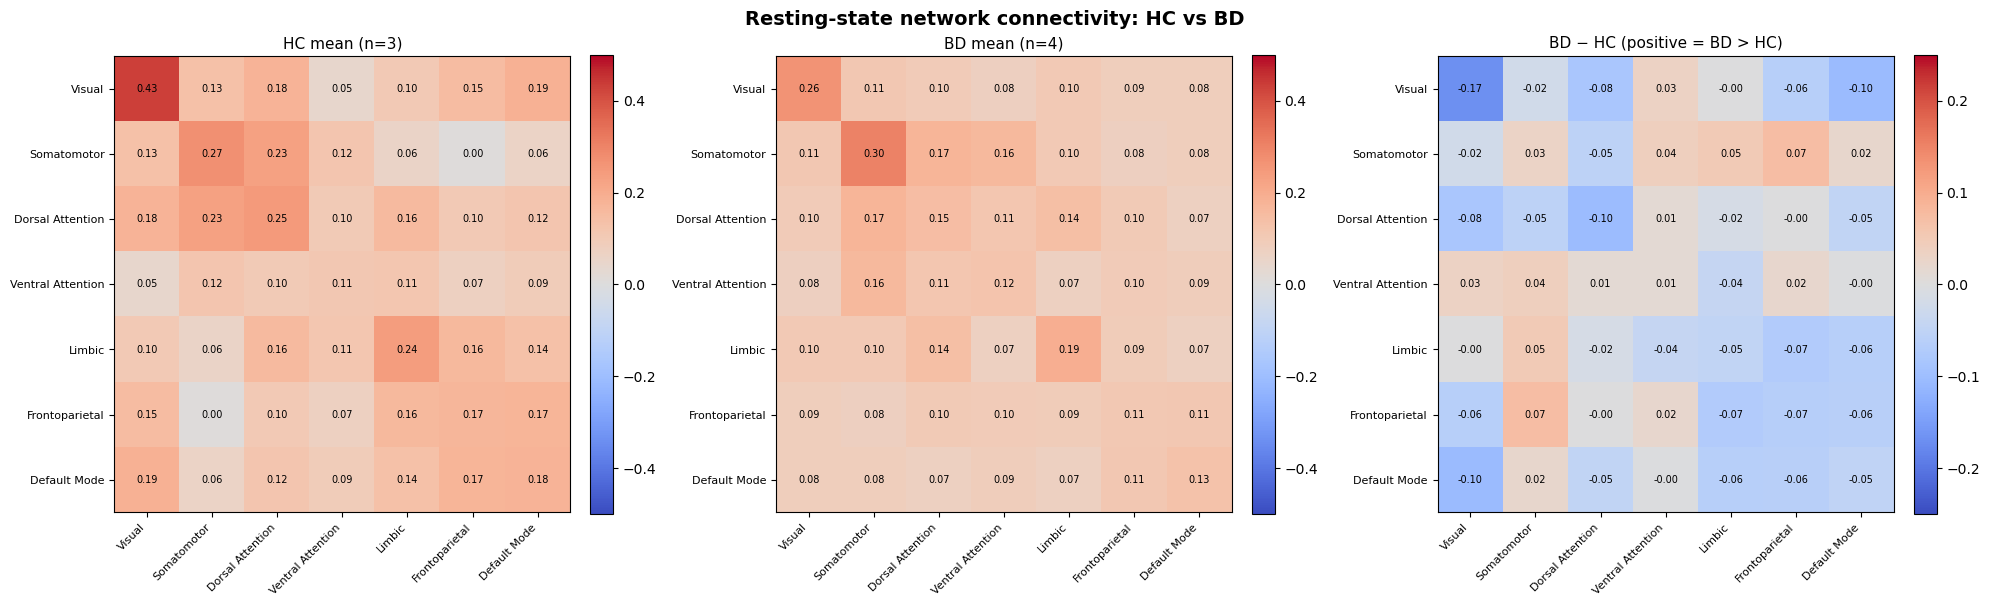

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ── GROUP-LEVEL ANALYSIS ─────────────────────────────────────────────────────

# Collect 7×7 matrices by group (only subjects that passed QC)
hc_net7 = [r["net7"] for r in results.values()
           if r["passed_qc"] and r["group"] == "HC"]
bd_net7 = [r["net7"] for r in results.values()
           if r["passed_qc"] and r["group"] == "BD"]

hc_mean = np.mean(hc_net7, axis=0)   # shape (7, 7)
bd_mean = np.mean(bd_net7, axis=0)
diff    = bd_mean - hc_mean          # BD − HC

print(f"HC subjects used: {[s for s,r in results.items() if r['passed_qc'] and r['group']=='HC']}")
print(f"BD subjects used: {[s for s,r in results.items() if r['passed_qc'] and r['group']=='BD']}")

full_names = [net_label_full[n] for n in unique_nets]

# Plot HC mean, BD mean, and BD−HC difference side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Resting-state network connectivity: HC vs BD", fontsize=14, fontweight="bold")

for ax, mat, title, vmax in zip(
    axes,
    [hc_mean, bd_mean, diff],
    [f"HC mean (n={len(hc_net7)})",
     f"BD mean (n={len(bd_net7)})",
     "BD − HC (positive = BD > HC)"],
    [0.5, 0.5, 0.25]   # color scales
):
    im = ax.imshow(mat, vmin=-vmax, vmax=vmax, cmap="coolwarm")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(7)); ax.set_xticklabels(full_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(7)); ax.set_yticklabels(full_names, fontsize=8)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()


# Run & Save 34 partipants 7x7 and view group level comparison - 4/6/26

In [57]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

base_dir = Path("/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/fmriprep")

def infer_group(sub):
    num = sub.replace("sub-", "")
    if num.startswith("10"):
        return "HC"
    elif num.startswith("6"):
        return "BD"
    return None

subjects = []
for p in sorted(base_dir.iterdir()):
    if p.is_dir() and p.name.startswith("sub-"):
        group = infer_group(p.name)
        if group is not None:
            subjects.append({"sub": p.name, "group": group, "path": p})

print(f"Found {len(subjects)} subjects")  # 34

# ── Atlas ────────────────────────────────────────────────────────────────────
atlas            = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img        = atlas.maps
atlas_img_loaded = nib.load(atlas_img) if isinstance(atlas_img, str) else atlas_img
atlas_data       = atlas_img_loaded.get_fdata()

atlas_labels = [l.decode() if isinstance(l, bytes) else l for l in atlas.labels]
network_names = []
for lbl in atlas_labels:
    parts = lbl.split("_")
    network_names.append(parts[2] if len(parts) > 2 else "Unknown")

unique_nets    = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
net_colors     = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf"]
net_label_full = {
    "Vis": "Visual", "SomMot": "Somatomotor", "DorsAttn": "Dorsal Attention",
    "SalVentAttn": "Ventral Attention", "Limbic": "Limbic",
    "Cont": "Frontoparietal", "Default": "Default Mode",
}

MEAN_FD_THRESHOLD  = 0.5
FD_SPIKE_THRESHOLD = 0.5

results = {}  # summary for all subjects

Found 34 subjects


[fetch_atlas_schaefer_2018] Dataset found in /Users/leilanytorresdiaz/nilearn_data/schaefer_2018

In [ ]:
out_root = Path("/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/connectivity")

from collections import Counter

results = {}
skipped_subjects = []
processed_subjects = []

for entry in subjects:
    sub   = entry["sub"]
    group = entry["group"]

    print(f"\n{'='*60}")
    print(f"  Processing {sub}  [{group}]")
    print(f"{'='*60}")

    func_dir       = base_dir / sub / "func"
    bold_file      = func_dir / f"{sub}_task-rest_bold_space-T1w_preproc.nii.gz"
    mask_file      = func_dir / f"{sub}_task-rest_bold_space-T1w_brainmask.nii.gz"
    confounds_file = func_dir / f"{sub}_task-rest_bold_confounds.tsv"

    missing = [p.name for p in [bold_file, mask_file, confounds_file] if not 
p.exists()]
    if missing:
        print(f" SKIPPING {sub} [{group}] - missing files:")
        for m in missing:
            print(f"  - {m}")
        skipped_subjects.append({"sub": sub, "group": group, "missing": missing})
        results[sub] ={
            "group": group,
            "passed_qc": False,
            "skip_reason": "missing_files",
            "mean_fd": None,
        }
        continue 
    # if files exist, continue normally
    processed_subjects.append({"sub": sub, "group": group})

    bold_img = nib.load(str(bold_file))
    mask_img = nib.load(str(mask_file))
    confounds = pd.read_csv(confounds_file, sep="\t")

    candidate_confounds = [
        "X","Y","Z","RotX","RotY","RotZ",
        "trans_x","trans_y","trans_z","rot_x","rot_y","rot_z",
        "trans_x_derivative1","trans_y_derivative1","trans_z_derivative1",
        "rot_x_derivative1","rot_y_derivative1","rot_z_derivative1",
        "WhiteMatter","CSF",
        "aCompCor00","aCompCor01","aCompCor02","aCompCor03","aCompCor04","aCompCor05",
        "FramewiseDisplacement","stdDVARS",
    ]
    confound_cols  = [c for c in candidate_confounds if c in confounds.columns]
    confounds_used = confounds[confound_cols].fillna(0)

    # ── Mean FD QC ───────────────────────────────────────────────────────────
    passed_qc = True
    mean_fd = None
    if "FramewiseDisplacement" in confounds.columns:
        mean_fd = confounds["FramewiseDisplacement"].iloc[1:].mean()
        print(f"  Mean FD: {mean_fd:.3f} mm")
        if mean_fd > MEAN_FD_THRESHOLD:
            print(f"  EXCLUDED — mean FD > {MEAN_FD_THRESHOLD} mm")
            passed_qc = False
    else:
        print("  No FramewiseDisplacement column — skipping FD check")

    # TR‑level scrubbing
    if "FramewiseDisplacement" in confounds.columns:
        fd_series  = confounds["FramewiseDisplacement"].fillna(0)
        spike_mask = fd_series > FD_SPIKE_THRESHOLD
        n_censored = spike_mask.sum()
        print(f"  TRs censored: {n_censored}/{len(fd_series)}")
        for tr_idx in np.where(spike_mask)[0]:
            col = np.zeros(len(confounds))
            col[tr_idx] = 1
            confounds_used[f"scrub_tr{tr_idx}"] = col

    # If you want to completely skip high‑motion subjects:
    if not passed_qc:
        results[sub] = {"group": group, "passed_qc": False, "mean_fd": float(mean_fd)}
        # still save minimal meta
        sub_out = out_root / sub
        sub_out.mkdir(parents=True, exist_ok=True)
        meta = {
            "sub": sub,
            "group": group,
            "passed_qc": False,
            "mean_fd": float(mean_fd),
            "good_rois": [],
        }
        with open(sub_out / "meta.json", "w") as f:
            json.dump(meta, f, indent=2)
        continue

    # ── Masker ───────────────────────────────────────────────────────────────
    masker = NiftiLabelsMasker(
        labels_img=atlas_img,
        mask_img=mask_img,
        standardize="zscore_sample",
        detrend=True,
        low_pass=0.1, high_pass=0.01, t_r=2.0,
        resampling_target="data",
        memory="nilearn_cache", verbose=0,
    )
    time_series = masker.fit_transform(bold_img, confounds=confounds_used)
    print(f"  Time series shape: {time_series.shape}")

    # Drop zero‑variance ROIs
    good_mask    = time_series.std(axis=0) > 0.01
    good_rois    = np.where(good_mask)[0]
    ts_clean     = time_series[:, good_rois]
    names_clean  = [network_names[i] for i in good_rois]
    labels_clean = [atlas_labels[i]  for i in good_rois]
    print(f"  Kept {len(good_rois)}/100 ROIs")

    # Correlation + Fisher z
    corr   = np.corrcoef(ts_clean.T)
    z_corr = np.arctanh(np.clip(corr, -0.999999, 0.999999))
    np.fill_diagonal(z_corr, 0)

    # 7×7 summary
    n_nets = len(unique_nets)
    net7   = np.zeros((n_nets, n_nets))
    for i, ni in enumerate(unique_nets):
        for j, nj in enumerate(unique_nets):
            idx_i = [k for k, n in enumerate(names_clean) if n == ni]
            idx_j = [k for k, n in enumerate(names_clean) if n == nj]
            if idx_i and idx_j:
                block = z_corr[np.ix_(idx_i, idx_j)]
                vals  = block[np.triu_indices(len(idx_i), k=1)] if i == j else block.ravel()
                net7[i, j] = vals.mean() if len(vals) > 0 else 0.0

    # ── Save per subject (matrix files + meta) ───────────────────────────────
    sub_out = out_root / sub
    sub_out.mkdir(parents=True, exist_ok=True)

    np.save(sub_out / "z_corr.npy", z_corr)   # full ROI x ROI
    np.save(sub_out / "net7.npy",   net7)     # 7 x 7

    meta = {
        "sub": sub,
        "group": group,
        "passed_qc": bool(passed_qc),
        "mean_fd": float(mean_fd),
        "good_rois": [int(i) for i in good_rois],
        "names_clean": names_clean,
        "labels_clean": labels_clean,k
    }
    with open(sub_out / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    # ── Update in‑memory results summary ─────────────────────────────────────
    results[sub] = {
        "group":       group,
        "passed_qc":   True,
        "mean_fd":     float(mean_fd),
        "net7":        net7,
        "z_corr":      z_corr,
        "good_rois":   good_rois,
        "names_clean": names_clean,
    }

print("\nLoop complete.")
print("Passed QC:", [s for s,r in results.items() if r["passed_qc"]])
print("Excluded: ", [s for s,r in results.items() if not r["passed_qc"]])


  Processing sub-10159  [HC]
  Mean FD: 0.152 mm
  TRs censored: 5/152
  Time series shape: (152, 100)
  Kept 89/100 ROIs

  Processing sub-10171  [HC]
  Mean FD: 0.369 mm
  TRs censored: 32/152
  Time series shape: (152, 100)
  Kept 99/100 ROIs

  Processing sub-10189  [HC]
  Mean FD: 0.188 mm
  TRs censored: 7/152
  Time series shape: (152, 100)
  Kept 99/100 ROIs

  Processing sub-10193  [HC]
 SKIPPING sub-10193 [HC] - missing files:
  - sub-10193_task-rest_bold_space-T1w_preproc.nii.gz
  - sub-10193_task-rest_bold_space-T1w_brainmask.nii.gz
  - sub-10193_task-rest_bold_confounds.tsv

  Processing sub-10206  [HC]
  Mean FD: 0.093 mm
  TRs censored: 0/152


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 73/100 ROIs

  Processing sub-10217  [HC]
  Mean FD: 0.108 mm
  TRs censored: 0/152


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 96/100 ROIs

  Processing sub-10225  [HC]
  Mean FD: 0.176 mm
  TRs censored: 3/152


...

  Time series shape: (152, 100)
  Kept 87/100 ROIs

  Processing sub-60037  [BD]
  Mean FD: 0.306 mm
  TRs censored: 16/152


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 90/100 ROIs

  Processing sub-60038  [BD]
  Mean FD: 0.091 mm
  TRs censored: 0/152


/opt/anaconda3/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:806: RuntimeWarning: invalid value encountered in divide
  return sum / numpy.asanyarray(count).astype(numpy.float64)


  Time series shape: (152, 100)
  Kept 99/100 ROIs

Loop complete.
Passed QC: ['sub-10159', 'sub-10171', 'sub-10189', 'sub-10206', 'sub-10217', 'sub-10225', 'sub-10227', 'sub-10228', 'sub-10235', 'sub-10249', 'sub-10273', 'sub-10274', 'sub-10280', 'sub-10290', 'sub-10292', 'sub-60010', 'sub-60011', 'sub-60012', 'sub-60014', 'sub-60015', 'sub-60016', 'sub-60020', 'sub-60021', 'sub-60022', 'sub-60028', 'sub-60030', 'sub-60033', 'sub-60036', 'sub-60037', 'sub-60038']
Excluded:  ['sub-10193', 'sub-10269', 'sub-10271', 'sub-60017']


In [61]:
# run CSV export

def net7_to_features(net7):
    net7 = np.asarray(net7)
    iu = np.triu_indices(net7.shape[0], k=1)
    return net7[iu]

rows = []
for sub, d in results.items():
    if not d["passed_qc"]:
        continue
    feats = net7_to_features(d["net7"])
    row = {"sub": sub, "group": d["group"], "mean_fd": d["mean_fd"]}
    for i, val in enumerate(feats):
        row[f"edge_{i:02d}"] = float(val)
    rows.append(row)

wide_df = pd.DataFrame(rows)
wide_df.to_csv(out_root / "net7_edges_wide.csv", index=False)

In [62]:
print(out_root)

/Users/leilanytorresdiaz/Desktop/rsFC_predictive_modeling_2026/Data/derivatives/connectivity
